# Heating Process - Process Variables

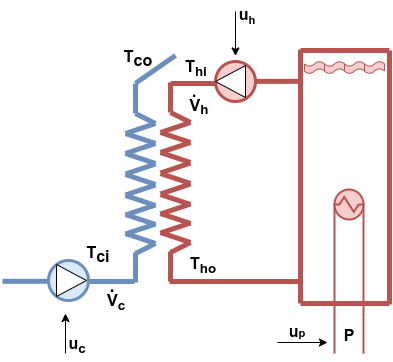

In [1]:
import os 
import random
import torch
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import train_test_split

## Remove rondomness from the notebook

In [2]:
def remove_randomness(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_num_threads(1) 
    torch.set_num_interop_threads(1)
    if platform.processor() == 'arm':
        torch.mps.manual_seed(seed)

seed = 42
remove_randomness(seed)

def seed_worker(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## Colab

In [3]:
# from google.colab import files
# files.upload()

## Loading data

In [4]:
if platform.system() == 'Windows':
    !dir
else:
    !ls

Heat_Process_Model_Final V1.ipynb   figures
Heat_Process_Testing_Final V1.ipynb multSineExp 1.csv
Heat_Process_Variables_Final.ipynb  paper.pdf
PRBS.csv                            paper.tex
Structured-abstract.docx            references.bib
Styles


In [5]:
# read data file
df = pd.read_csv('PRBS.csv', delimiter=";")
df.head()

,0.00E+00,0.00E+00.1,0.00E+00.2,0.00E+00.3,0.00E+00.4,0.00E+00.5,0.00E+00.6,0.00E+00.7,0.00E+00.8,0.00E+00.9
0,0.0,0.000,0.00000,0.0000,0.0000,0.0733,0.0733,1.0,1.0,25.0
1,0.0,0.000,0.00000,0.0733,0.0000,0.0000,-0.0733,2.0,2.0,25.0
2,0.0,-0.244,-0.00122,-0.0733,0.0000,0.0000,0.0733,3.0,3.0,25.0
3,0.0,0.000,0.00000,0.0733,0.0733,0.0733,0.0000,4.0,4.0,25.0
4,0.0,0.000,0.00000,0.0000,0.0000,-0.0733,0.0000,5.0,5.0,25.0


In [6]:
columns = ['L_in', 'V_c [ml/min]', 'P [kW]', 'T_ho [°C]', 'T_hi [°C]', 'T_ci [°C]', 'T_co [°C]', 'u_c [%]', 'u_h [%]', 'u_p [%]']
df.columns = columns

In [7]:
df.describe()

,L_in,V_c [ml/min],P [kW],T_ho [°C],T_hi [°C],T_ci [°C],T_co [°C],u_c [%],u_h [%],u_p [%]
count,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000
mean,19.169327,33.413782,0.079282,5.171392,7.649166,1.847576,5.631319,10.910966,9.456768,4.803806
std,46.610022,78.871288,0.213907,11.883784,17.490006,4.207372,12.881252,25.462560,22.704181,13.054138
min,0.000000,-0.244000,-0.001220,-0.073300,-0.073300,-0.073300,-0.073300,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,219.000000,287.000000,1.580000,43.300000,57.600000,16.600000,45.700000,80.000000,80.000000,95.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14399 entries, 0 to 14398
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   L_in          14399 non-null  float64
 1   V_c [ml/min]  14399 non-null  float64
 2   P [kW]        14399 non-null  float64
 3   T_ho [°C]     14399 non-null  float64
 4   T_hi [°C]     14399 non-null  float64
 5   T_ci [°C]     14399 non-null  float64
 6   T_co [°C]     14399 non-null  float64
 7   u_c [%]       14399 non-null  float64
 8   u_h [%]       14399 non-null  float64
 9   u_p [%]       14399 non-null  float64
dtypes: float64(10)
memory usage: 1.1 MB


<Axes: >

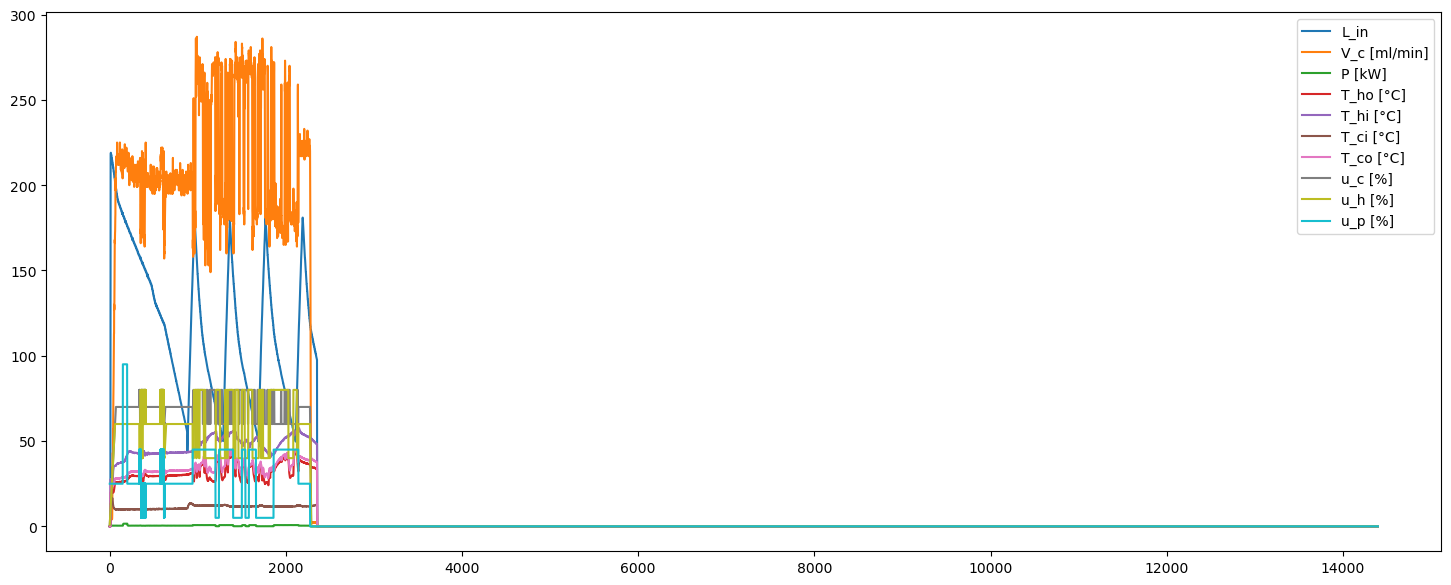

In [9]:
df.plot(figsize = [18,7])

In [10]:
start = 942
end = 2143
df = df[start:end]
len(df)

1201

<Axes: >

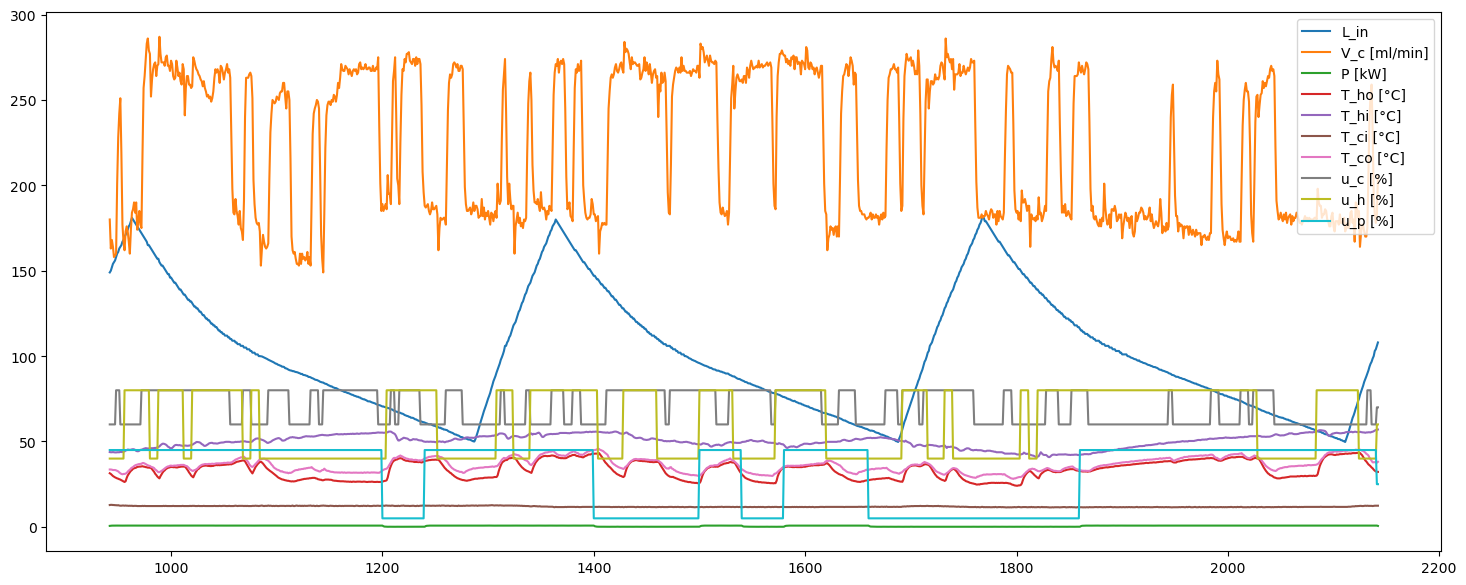

In [11]:
df.plot(figsize = [18,7])

In [12]:
df = df.reset_index(drop=True)

## Ploting the original data

<Axes: >

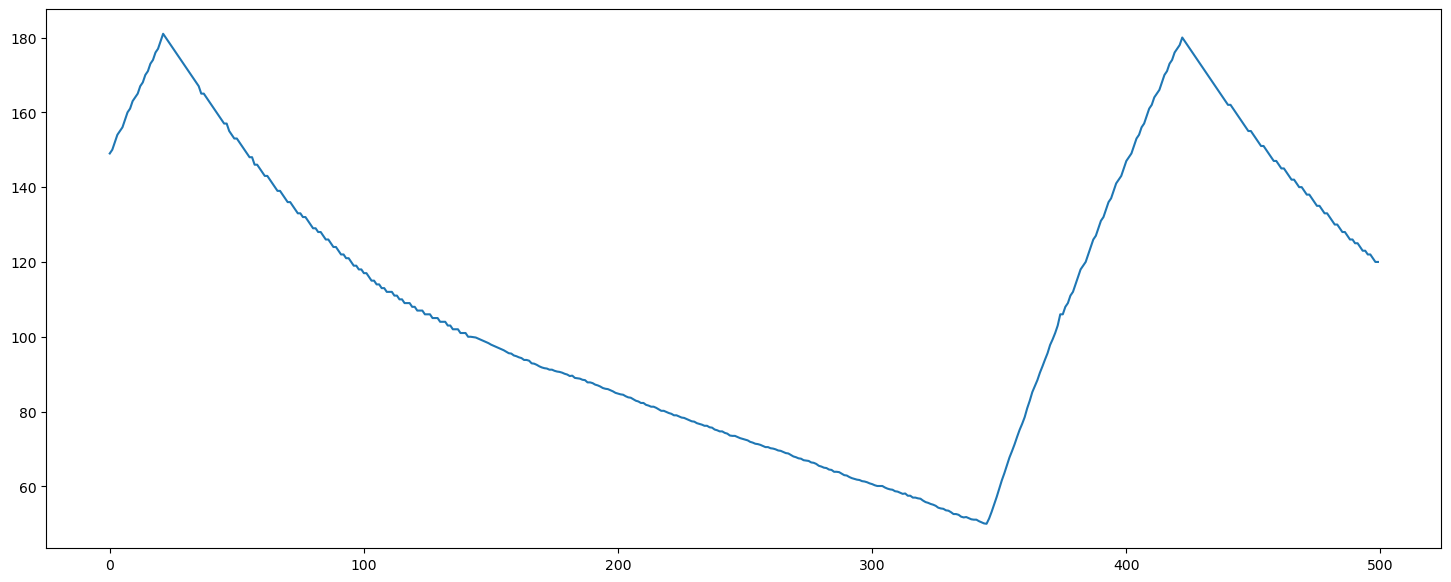

In [13]:
df['L_in'][0:500].plot(figsize = [18,7])

<Axes: >

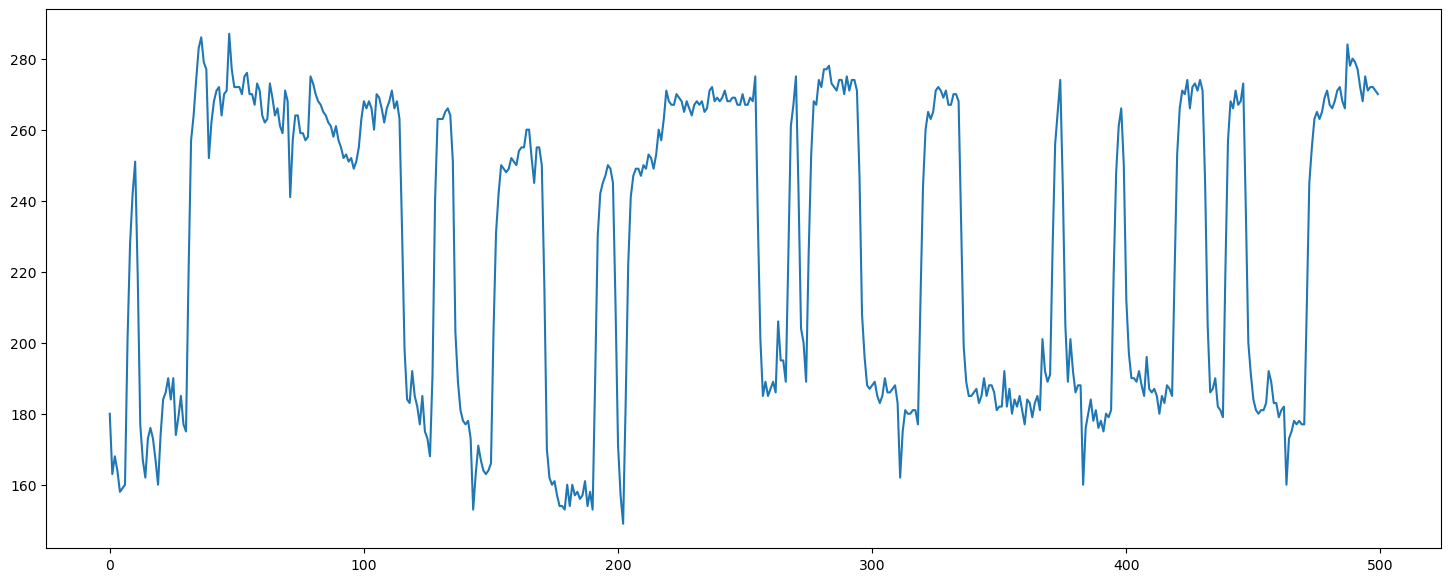

In [14]:
df['V_c [ml/min]'][0:500].plot(figsize = [18,7])

<Axes: >

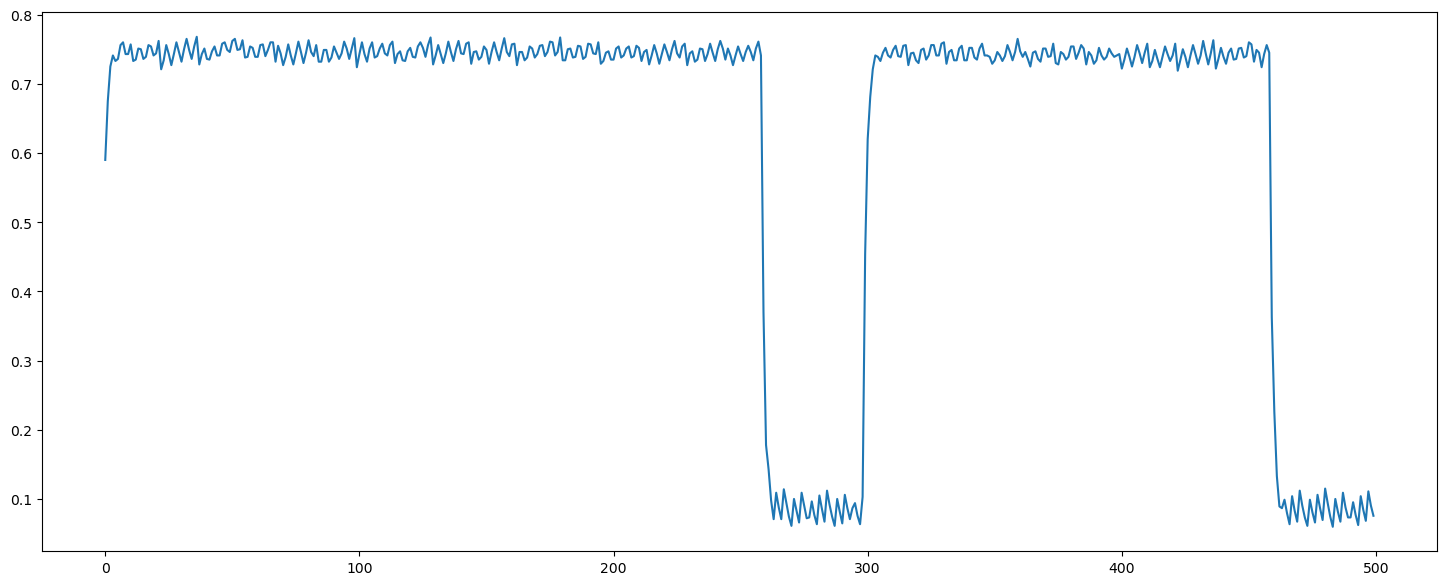

In [15]:
df['P [kW]'][0:500].plot(figsize = [18,7])

<Axes: >

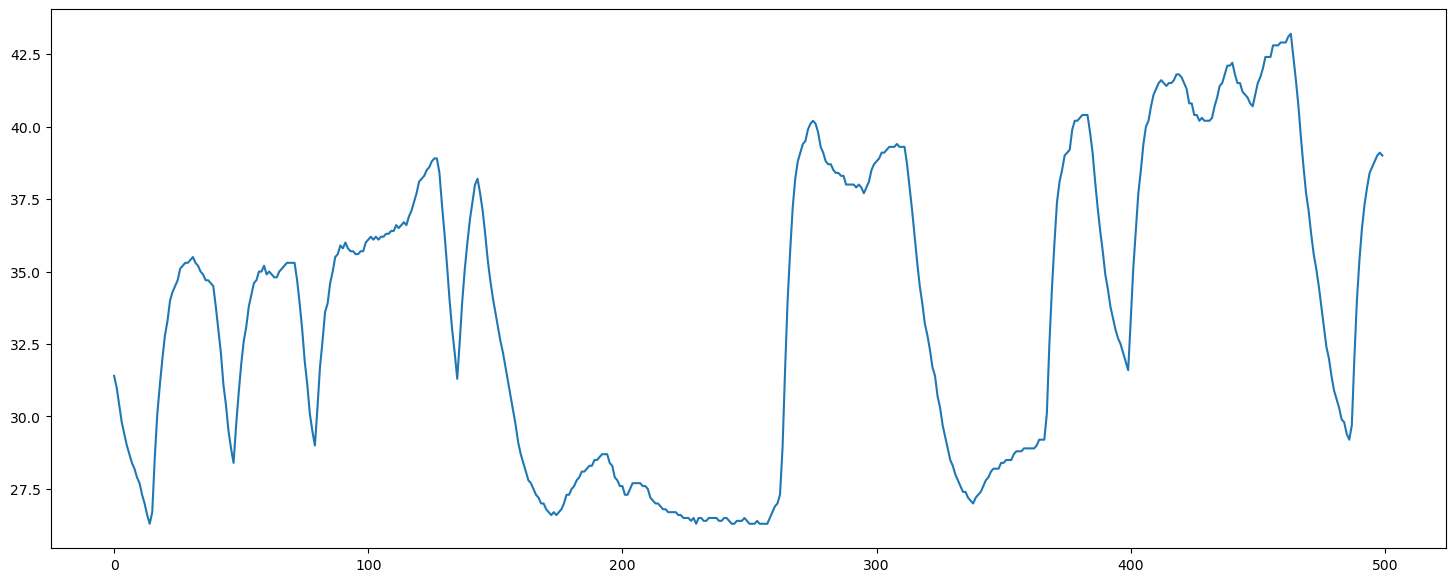

In [16]:
df['T_ho [°C]'][0:500].plot(figsize = [18,7])

<Axes: >

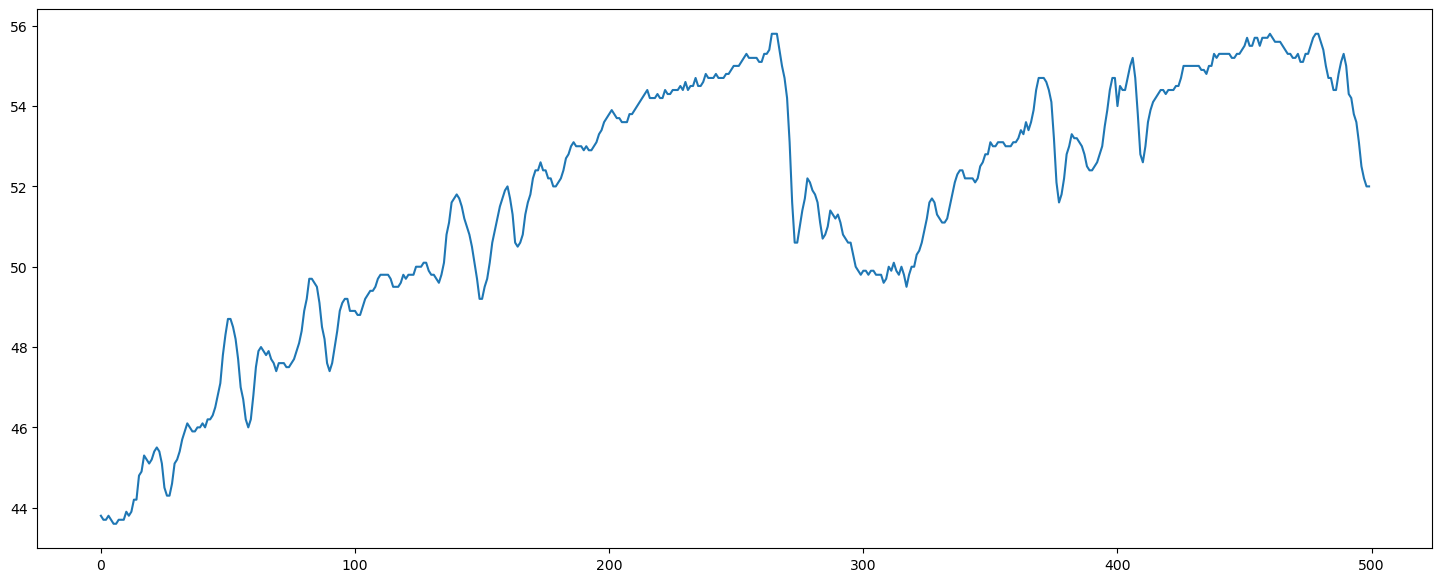

In [17]:
df['T_hi [°C]'][0:500].plot(figsize = [18,7])

<Axes: >

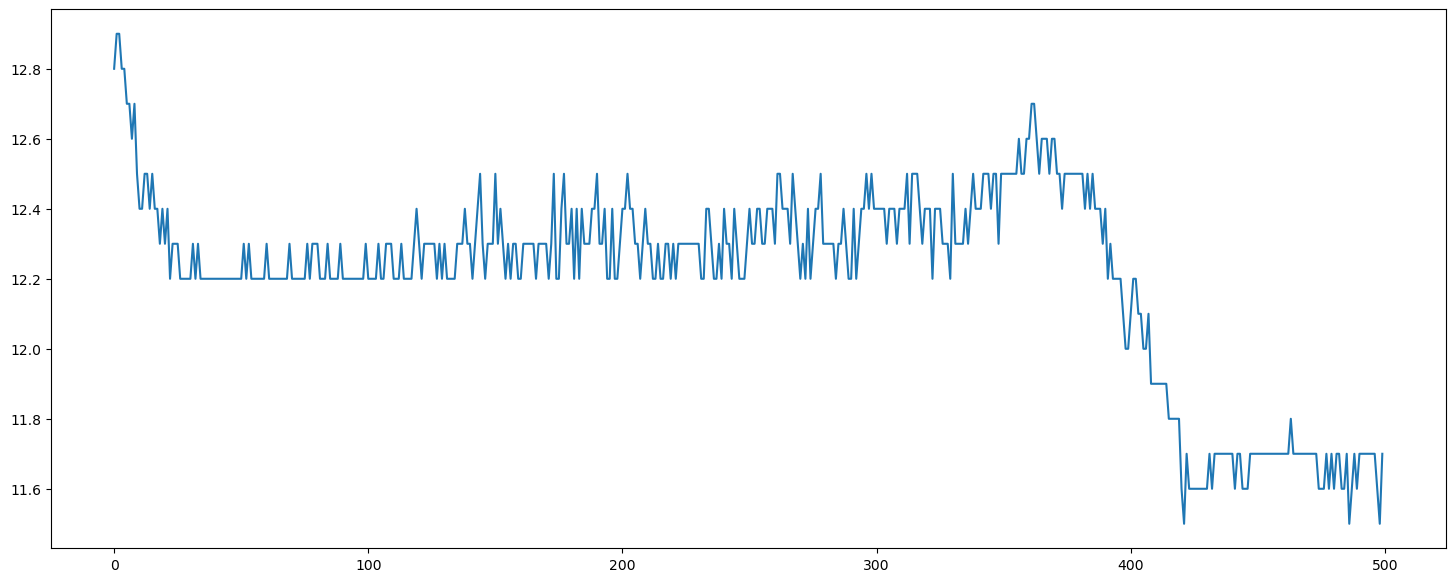

In [18]:
df['T_ci [°C]'][0:500].plot(figsize = [18,7])

<Axes: >

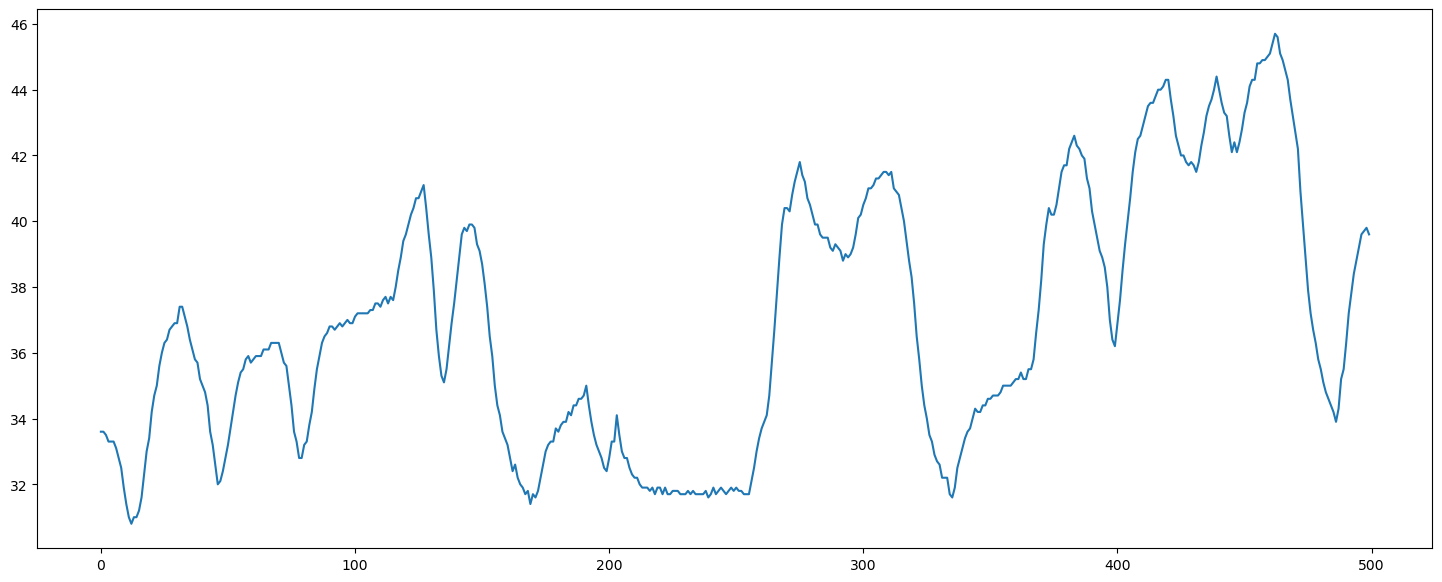

In [19]:
df['T_co [°C]'][0:500].plot(figsize = [18,7])

<Axes: >

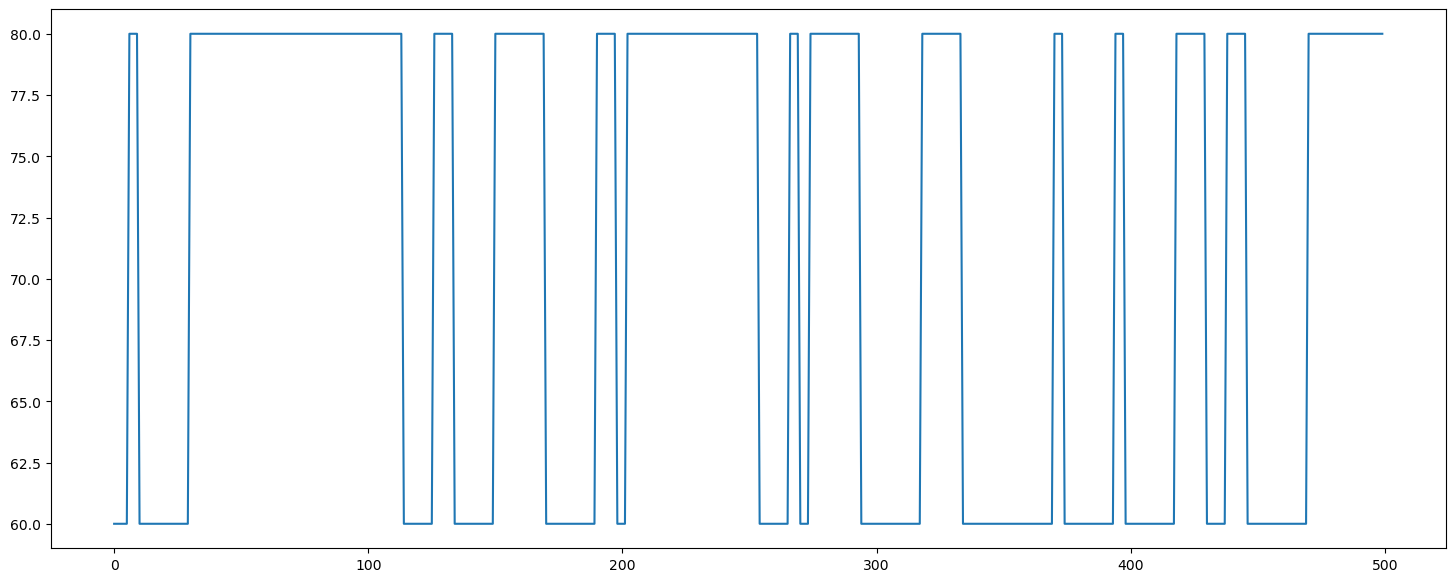

In [20]:
df['u_c [%]'][0:500].plot(figsize = [18,7])

<Axes: >

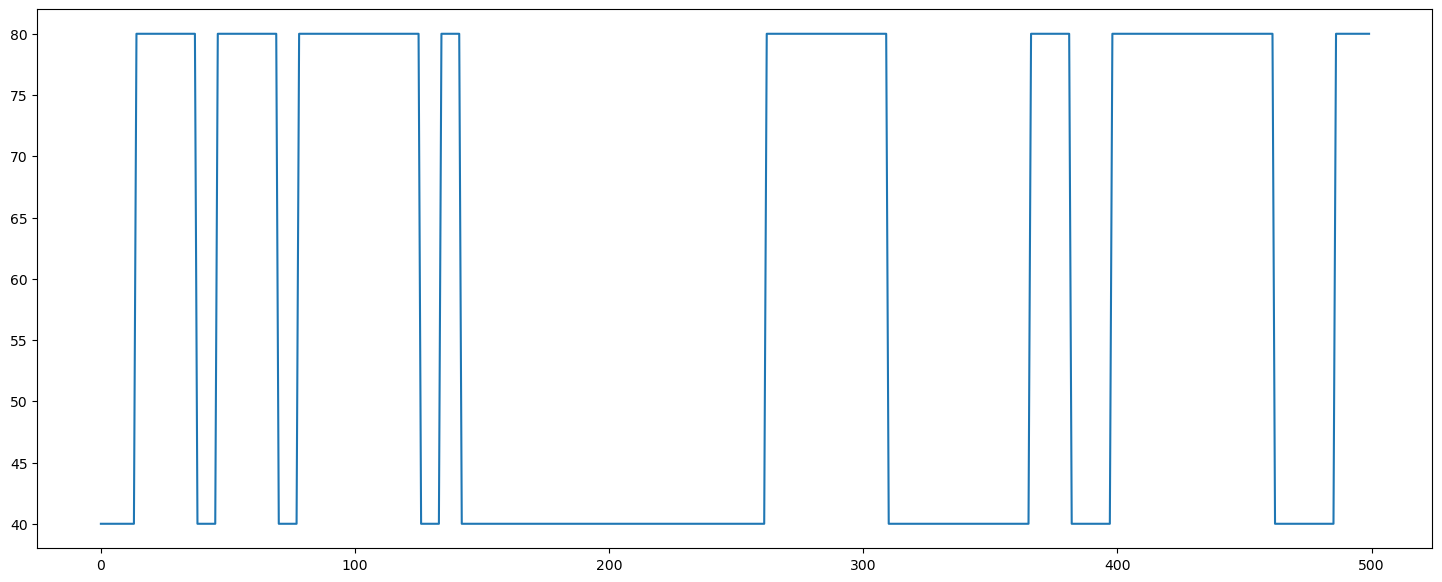

In [21]:
df['u_h [%]'][0:500].plot(figsize = [18,7])

<Axes: >

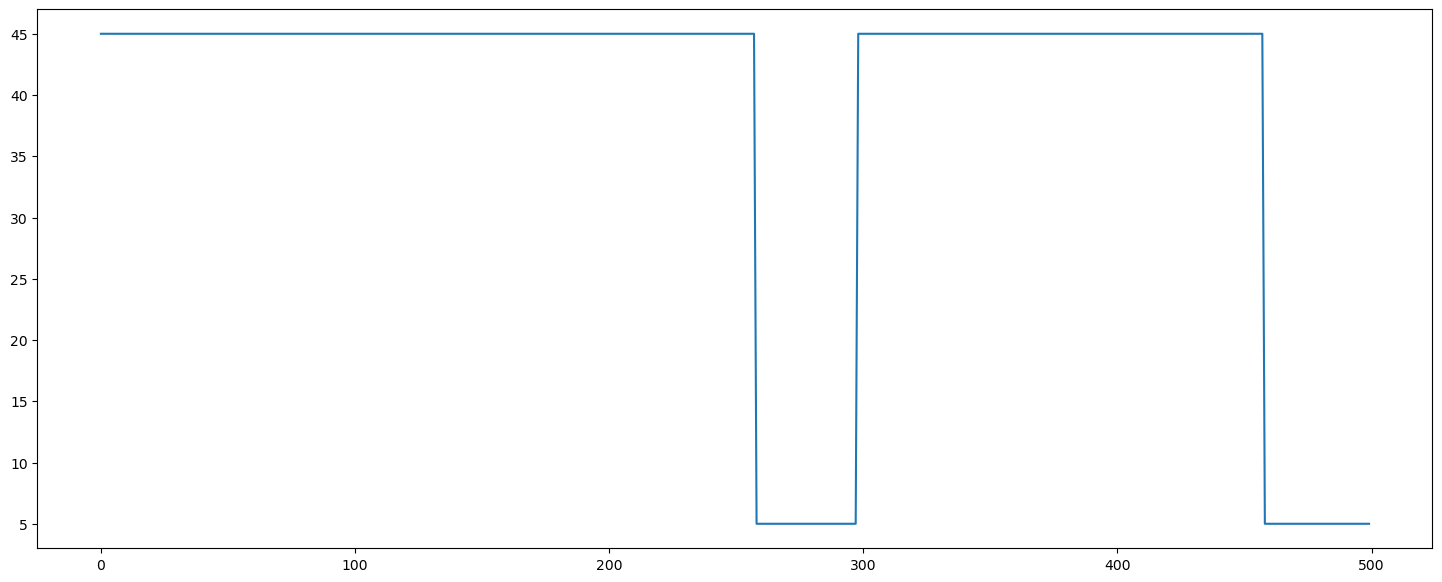

In [22]:
df['u_p [%]'][0:500].plot(figsize = [18,7])

In [23]:
# shifted variables
df['u_p_k-1 [%]'] = df['u_p [%]'].shift(1)
df['u_p_k-2 [%]'] = df['u_p [%]'].shift(2)

df['u_h_k-1 [%]'] = df['u_h [%]'].shift(1)
df['u_h_k-2 [%]'] = df['u_h [%]'].shift(2)

df['u_c_k-1 [%]'] = df['u_c [%]'].shift(1)
df['u_c_k-2 [%]'] = df['u_c [%]'].shift(2)
df['u_c_k-3 [%]'] = df['u_c [%]'].shift(3)

df['P_k-1 [kW]'] = df['P [kW]'].shift(1)
df['P_k-2 [kW]'] = df['P [kW]'].shift(2)

df['V_c_k-1 [ml/min]'] = df['V_c [ml/min]'].shift(1)
df['V_c_k-2 [ml/min]'] = df['V_c [ml/min]'].shift(2)

# if missing values then use old values
df = df.ffill()
df = df.bfill()

df

,L_in,V_c [ml/min],P [kW],T_ho [°C],T_hi [°C],T_ci [°C],T_co [°C],u_c [%],u_h [%],u_p [%],...,u_p_k-2 [%],u_h_k-1 [%],u_h_k-2 [%],u_c_k-1 [%],u_c_k-2 [%],u_c_k-3 [%],P_k-1 [kW],P_k-2 [kW],V_c_k-1 [ml/min],V_c_k-2 [ml/min]
0,149.0,180.0,0.590,31.4,43.8,12.8,33.6,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.590,0.590,180.0,180.0
1,150.0,163.0,0.675,31.0,43.7,12.9,33.6,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.590,0.590,180.0,180.0
2,152.0,168.0,0.725,30.4,43.7,12.9,33.5,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.675,0.590,163.0,180.0
3,154.0,164.0,0.741,29.8,43.8,12.8,33.3,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.725,0.675,168.0,163.0
4,155.0,158.0,0.733,29.4,43.7,12.8,33.3,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.741,0.725,164.0,168.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,100.0,195.0,0.736,33.5,56.0,12.3,37.8,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,80.0,0.750,0.735,231.0,259.0
1197,103.0,183.0,0.727,32.9,56.4,12.4,37.9,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.736,0.750,195.0,231.0
1198,104.0,178.0,0.741,32.5,56.7,12.4,37.9,60.0,40.0,45.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.727,0.736,183.0,195.0
1199,106.0,183.0,0.752,32.2,56.9,12.4,37.6,70.0,60.0,25.0,...,45.0,40.0,40.0,60.0,60.0,60.0,0.741,0.727,178.0,183.0


## Process vairable V_c

<Axes: >

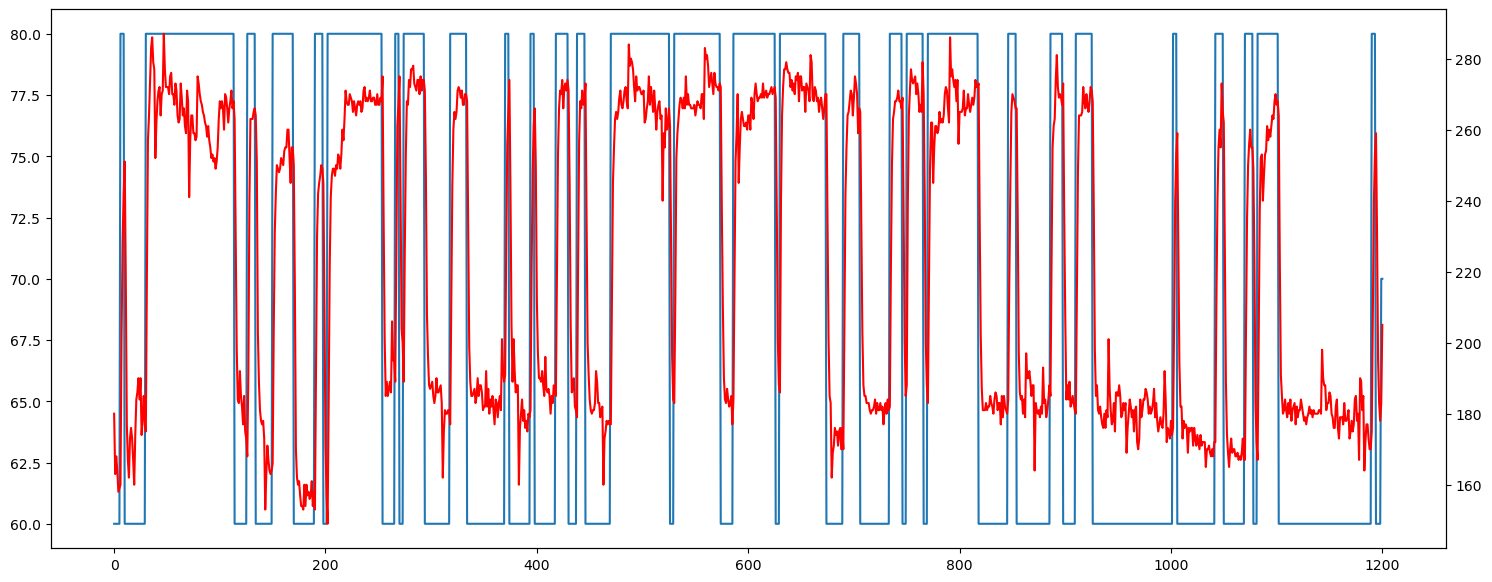

In [24]:
df['u_c [%]'].plot()
df['V_c [ml/min]'].plot(secondary_y=True, color='red', figsize = [18,7])

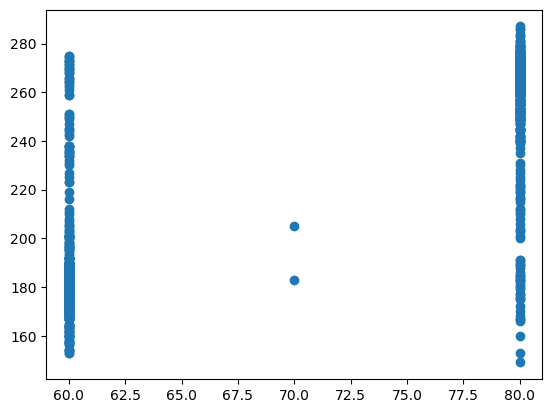

In [25]:
x = df['u_c [%]']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

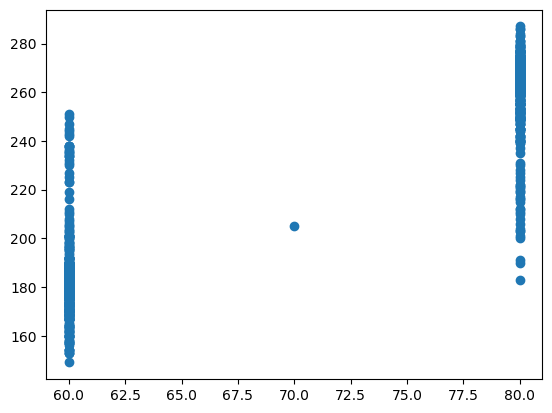

In [26]:
x = df['u_c_k-1 [%]']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

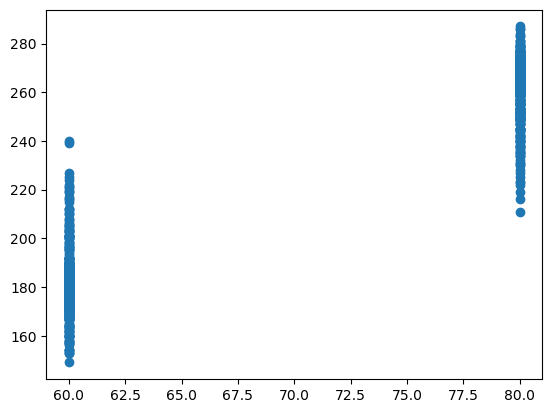

In [27]:
x = df['u_c_k-2 [%]']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

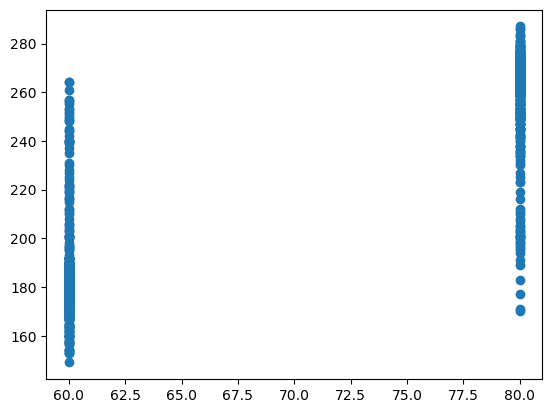

In [28]:
x = df['u_c_k-3 [%]']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

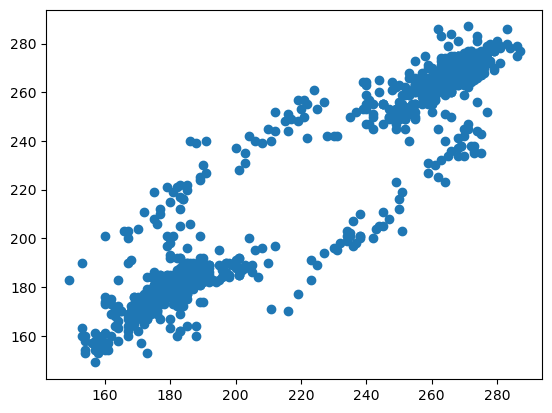

In [29]:
x = df['V_c_k-1 [ml/min]']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

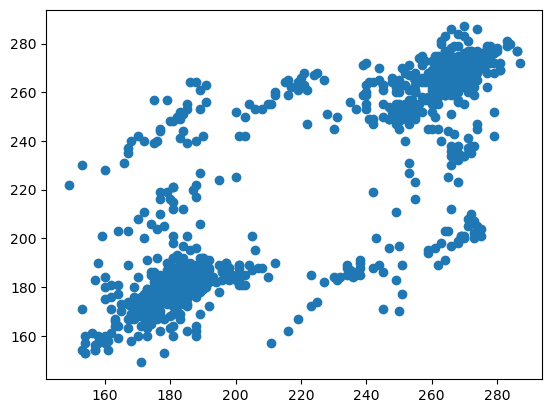

In [30]:
x = df['V_c_k-2 [ml/min]']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

In [31]:
Ts = 1
K = 5
T = 1.5

df['V_c_est'] = Ts*K/T*np.maximum(df['u_c_k-1 [%]']-19.0, 0.0) + (1 - Ts/T) * df['V_c_k-1 [ml/min]']

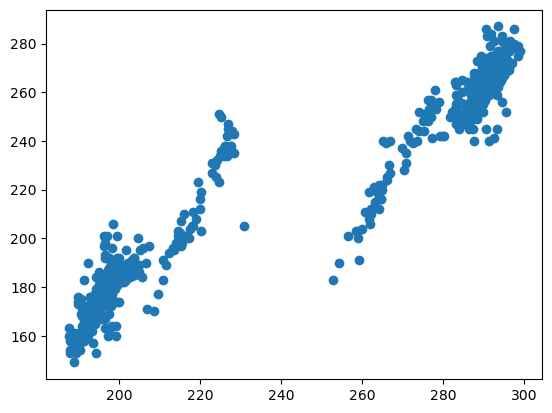

In [32]:
x = df['V_c_est']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

<Axes: >

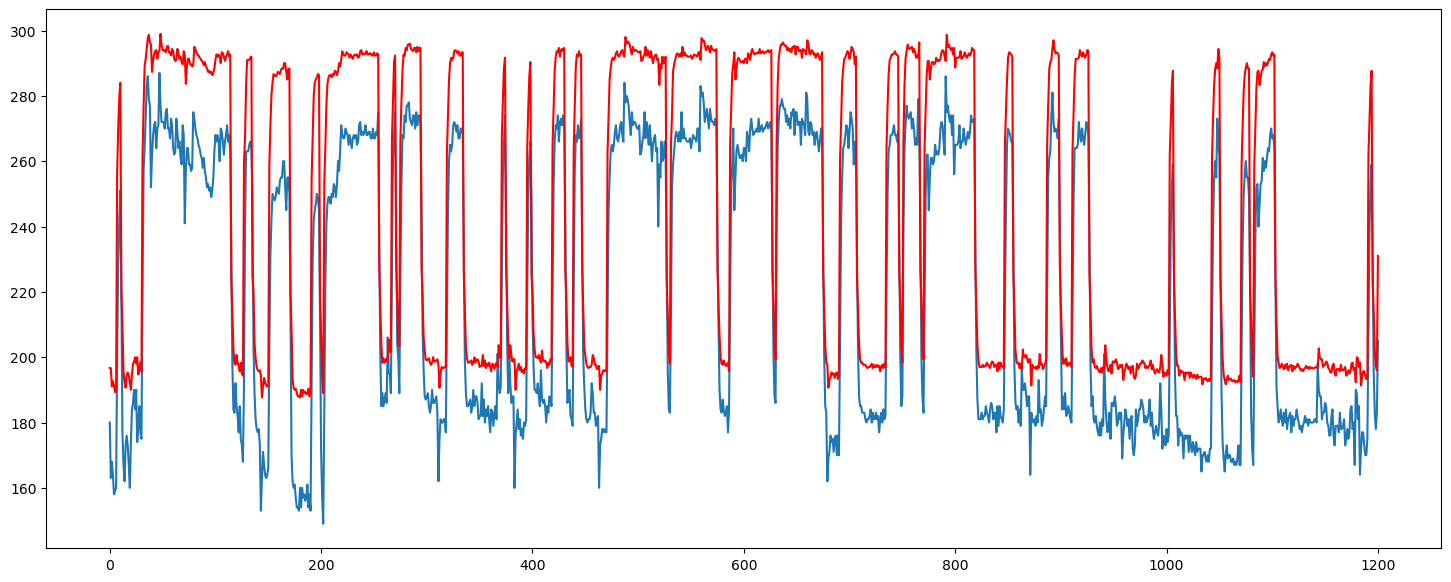

In [33]:
df['V_c [ml/min]'].plot()
df['V_c_est'].plot(color = 'red', figsize = [18,7])

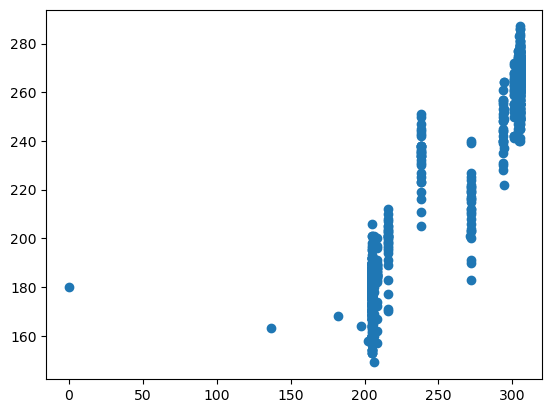

In [34]:
# Initialize the 'new' column with NaN
df['V_c_est_2a'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'V_c_est_2a'] = 0.0

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'V_c_est_2a'] = Ts*K/T*np.maximum(df.at[i-1, 'u_c [%]'] - 19.0, 0.0) + (1 - Ts/T)*df.at[i-1, 'V_c_est_2a'] 

x = df['V_c_est_2a']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

In [35]:
# Starting point
df.at[0, 'V_c [ml/min]']

180.0

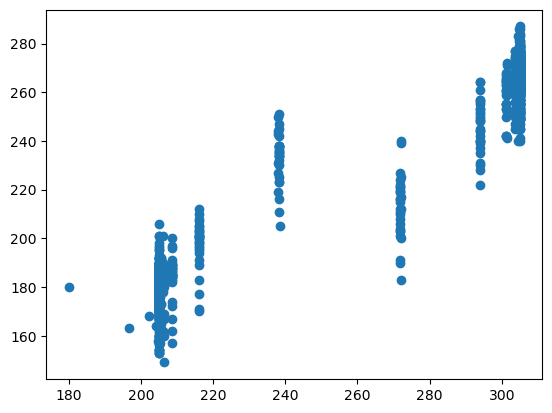

In [36]:
# Correct starting point

# Initialize the 'new' column with NaN
df['V_c_est_2b'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'V_c_est_2b'] = 180.0

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'V_c_est_2b'] = Ts*K/T*np.maximum(df.at[i-1, 'u_c [%]'] - 19.0, 0.0) + (1 - Ts/T)*df.at[i-1, 'V_c_est_2b']  

x = df['V_c_est_2b']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

<Axes: >

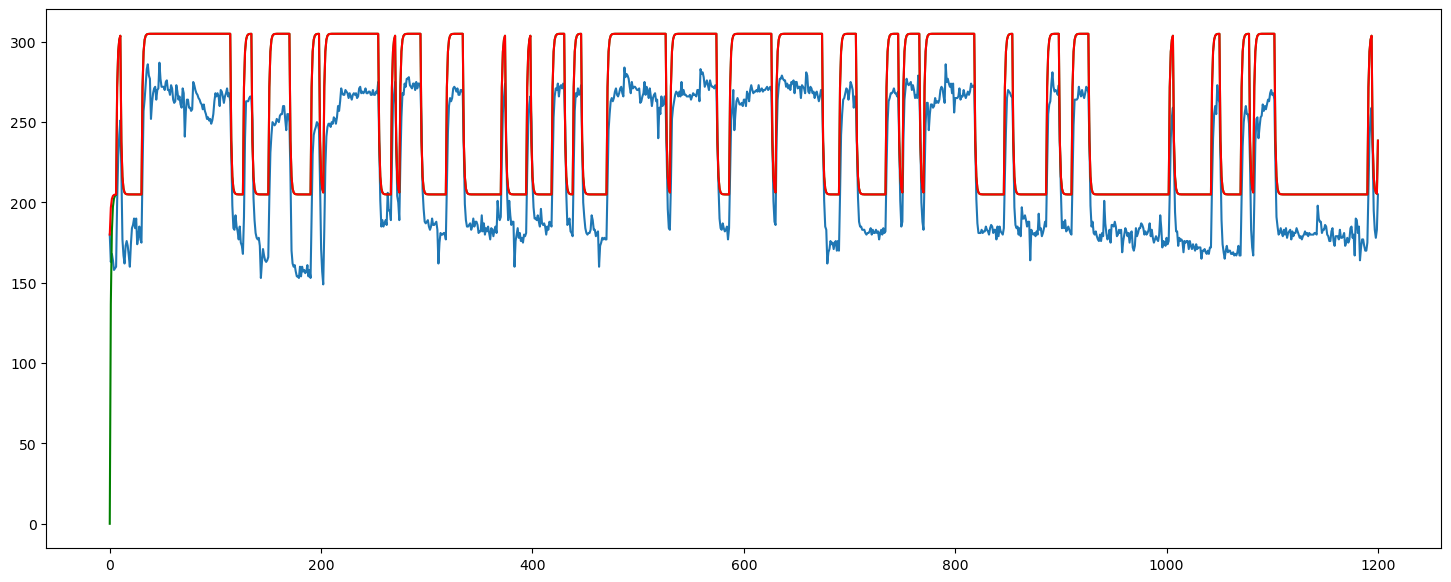

In [37]:
df['V_c [ml/min]'].plot()
df['V_c_est_2a'].plot(color = 'green')
df['V_c_est_2b'].plot(color = 'red', figsize = [18,7])

In [38]:
# Device
if torch.backends.mps.is_available():
    device ='mps'
elif torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'
device

'mps'

In [39]:
# split data in training, validation and test dataset 70 %, 15%, 15%
train_df, test_df = train_test_split(df,train_size=0.7, shuffle = False, random_state = seed)
valid_df, test_df = train_test_split(test_df,train_size=0.5, shuffle = False, random_state = seed)

In [40]:
# Dataset
from torch.utils.data import Dataset
class MyDataset(Dataset):

  def __init__(self,df,features, targets):
    self.X=torch.tensor(df[features].values, dtype=torch.float32)
    self.y=torch.tensor(df[targets].values, dtype=torch.float32)
    
  def __len__(self):
    return len(self.y)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [41]:
features = ['u_c_k-1 [%]', 'V_c_k-1 [ml/min]']
targets = ['V_c [ml/min]']

In [42]:
# Dataloader
from torch.utils.data import DataLoader

train_myDs=MyDataset(train_df, features, targets)
train_dataloader = DataLoader(train_myDs,batch_size=512,shuffle=True, worker_init_fn=seed_worker)

valid_myDs=MyDataset(valid_df, features, targets)
valid_dataloader = DataLoader(valid_myDs,batch_size=512,shuffle=True, worker_init_fn=seed_worker)

test_myDs=MyDataset(test_df, features, targets)
test_dataloader = DataLoader(test_myDs,batch_size=512,shuffle=True, worker_init_fn=seed_worker)

In [43]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device),  y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def test(dataloader, model, loss_fn, loss_fn2, min_loss, model_save_path="best_model_pv.pth", print_result = False):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss_MSE = 0.0
    test_loss_MAE = 0.0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss_MSE += loss_fn(pred, y) 
            test_loss_MAE += loss_fn2(pred, y)            
    test_loss_MSE /= num_batches
    test_loss_MAE /= num_batches
    if print_result:
        print(f"MSE: {test_loss_MSE:>8f}, MAE: {test_loss_MAE:>8f}")
        
    if test_loss_MSE < min_loss:
        print(f"New best model found! Saving model, MSE: {test_loss_MSE:>8f}, MAE: {test_loss_MAE:>8f}")
        torch.save(model.state_dict(), model_save_path)  # Save model
        min_loss = test_loss_MSE  # Update the minimum loss

    return min_loss
    
def testing(dataloader, model, loss_fn, loss_fn2, model_save_path="best_model_pv.pth"):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    test_loss_MSE = 0.0
    test_loss_MAE = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss_MSE += loss_fn(pred, y) 
            test_loss_MAE += loss_fn2(pred, y) 
            columns = pred.size()[1]
            for i in range(columns):
                plt.scatter(pred[:,i].to('cpu'), y[:,i].to('cpu'))
                plt.show()
        
    test_loss_MSE /= num_batches
    test_loss_MAE /= num_batches
    print(f"Avg loss MSE: {test_loss_MSE:>8f}, MAE: {test_loss_MAE:>8f}\n")

In [44]:
# model
class ProcessModel(torch.nn.Module):
    def __init__(self):
        super(ProcessModel, self).__init__()
        self.const_1 = torch.nn.Parameter(torch.rand(1,1))
        self.const_2 = torch.nn.Parameter(torch.rand(1,1))
        self.min_u = torch.tensor(19.0)
        
    def forward(self, x):
        # ['u_c_k-1 [%]', 'V_c_k-1 [ml/min]']
        x = self.const_1*torch.max(x[:,0]-self.min_u, torch.tensor(0.0)) + self.const_2*x[:,1]
        x = x.transpose(0, 1)
        return x

In [45]:
# Define loss function and optimizer
loss_fn = nn.MSELoss()
loss_fn2 = nn.L1Loss()
# Load model 1 to device
model = ProcessModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [46]:
epochs = 5000
min_loss = float('inf')
for t in range(epochs):
    if (t + 1) % 100 == 0:  # Print every 100 epochs
        print(f"Epoch {t+1}: ")
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=True)
    else:
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=False)
print("Done!")

New best model found! Saving model, MSE: 371.969788, MAE: 17.558395
New best model found! Saving model, MSE: 185.279739, MAE: 11.709590
New best model found! Saving model, MSE: 127.250565, MAE: 9.229818
New best model found! Saving model, MSE: 74.684631, MAE: 5.993836
New best model found! Saving model, MSE: 67.661186, MAE: 5.484921
New best model found! Saving model, MSE: 65.826584, MAE: 5.421340
New best model found! Saving model, MSE: 64.415833, MAE: 5.443955
New best model found! Saving model, MSE: 60.726498, MAE: 5.249574
New best model found! Saving model, MSE: 60.309597, MAE: 5.326549
New best model found! Saving model, MSE: 60.262360, MAE: 5.277426
New best model found! Saving model, MSE: 57.463097, MAE: 5.134088
New best model found! Saving model, MSE: 56.208916, MAE: 5.135483
New best model found! Saving model, MSE: 54.000202, MAE: 5.018847
New best model found! Saving model, MSE: 53.924072, MAE: 5.066190
New best model found! Saving model, MSE: 52.760838, MAE: 4.966803
New b

In [47]:
model.load_state_dict(torch.load("best_model_pv.pth"))

<All keys matched successfully>

In [48]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

const_1 tensor([[1.8883]], device='mps:0')
const_2 tensor([[0.5719]], device='mps:0')


In [49]:
model.const_1.item()

1.8882533311843872

In [50]:
model.const_2.item()

0.5718924403190613

In [51]:
model.min_u.item()

19.0

In [52]:
T_s = 1
T = T_s / (1.0 - model.const_2.item())
T

2.3358615782101184

In [53]:
K = model.const_1.item() / (T_s / T)
K

4.4106984062408765

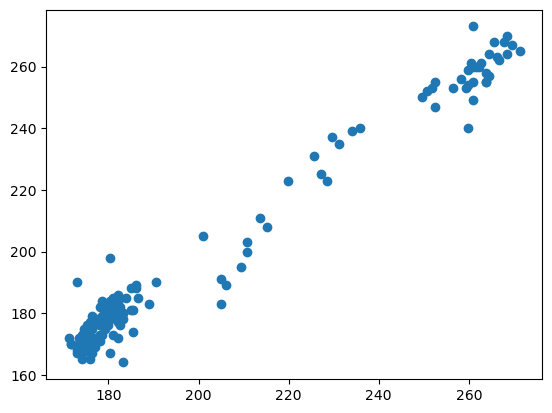

Avg loss MSE: 34.152161, MAE: 4.252729



In [54]:
testing(test_dataloader, model, loss_fn, loss_fn2)

In [55]:
df['V_c_est_3'] = model.const_1.item()*np.maximum(df['u_c_k-1 [%]']-19.0, 0.0) + model.const_2.item()*df['V_c_k-1 [ml/min]']

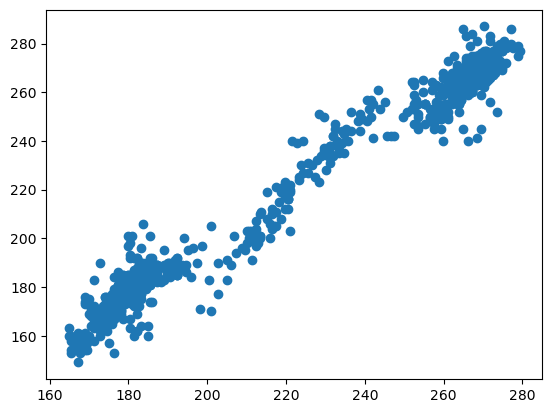

In [56]:
x = df['V_c_est_3']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

<Axes: >

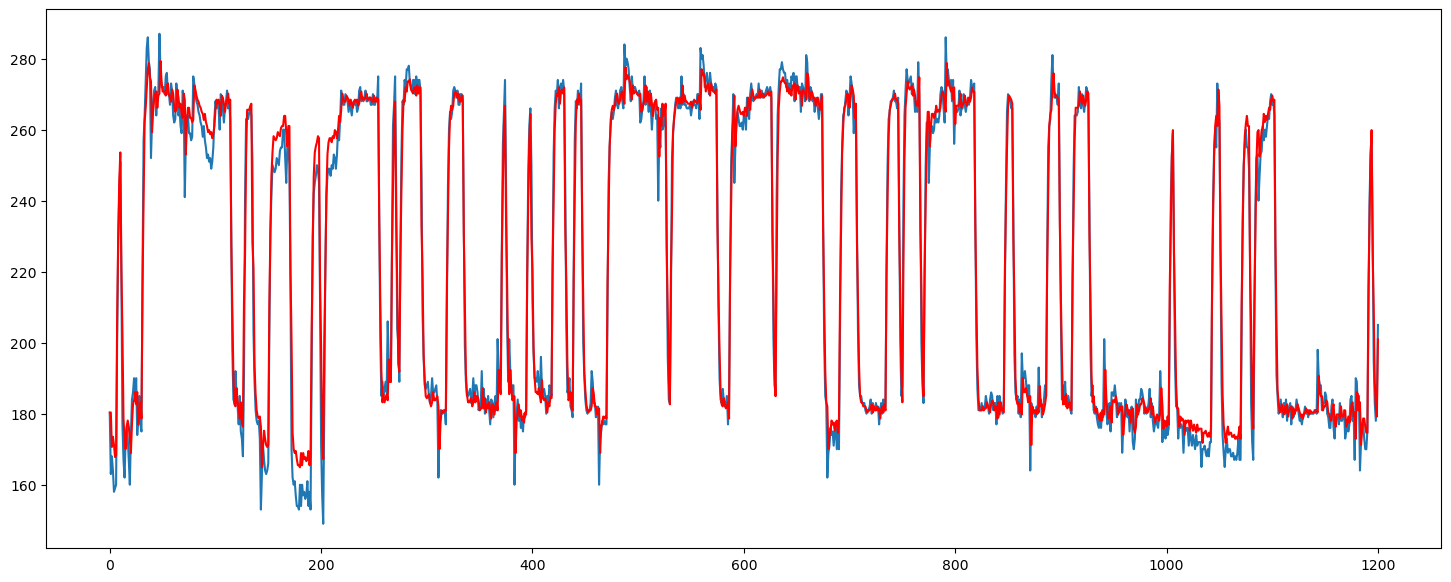

In [57]:
df['V_c [ml/min]'].plot()
df['V_c_est_3'].plot(color = 'red', figsize = [18,7])

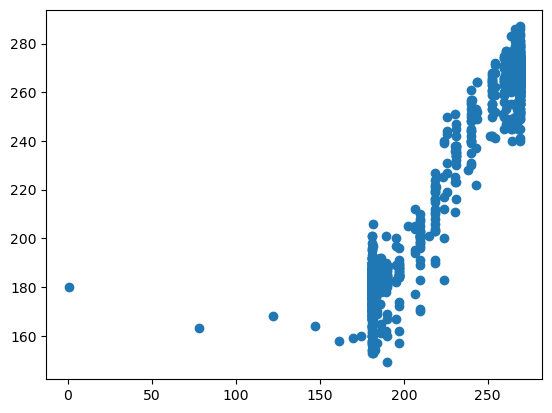

In [58]:
# Initialize the 'new' column with NaN
df['V_c_est_4'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'V_c_est_4'] = 0.59

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'V_c_est_4'] = model.const_1.item()*np.maximum(df.at[i-1, 'u_c [%]'] - 19.0, 0.0) + model.const_2.item()*df.at[i-1, 'V_c_est_4'] 

x = df['V_c_est_4']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

<Axes: >

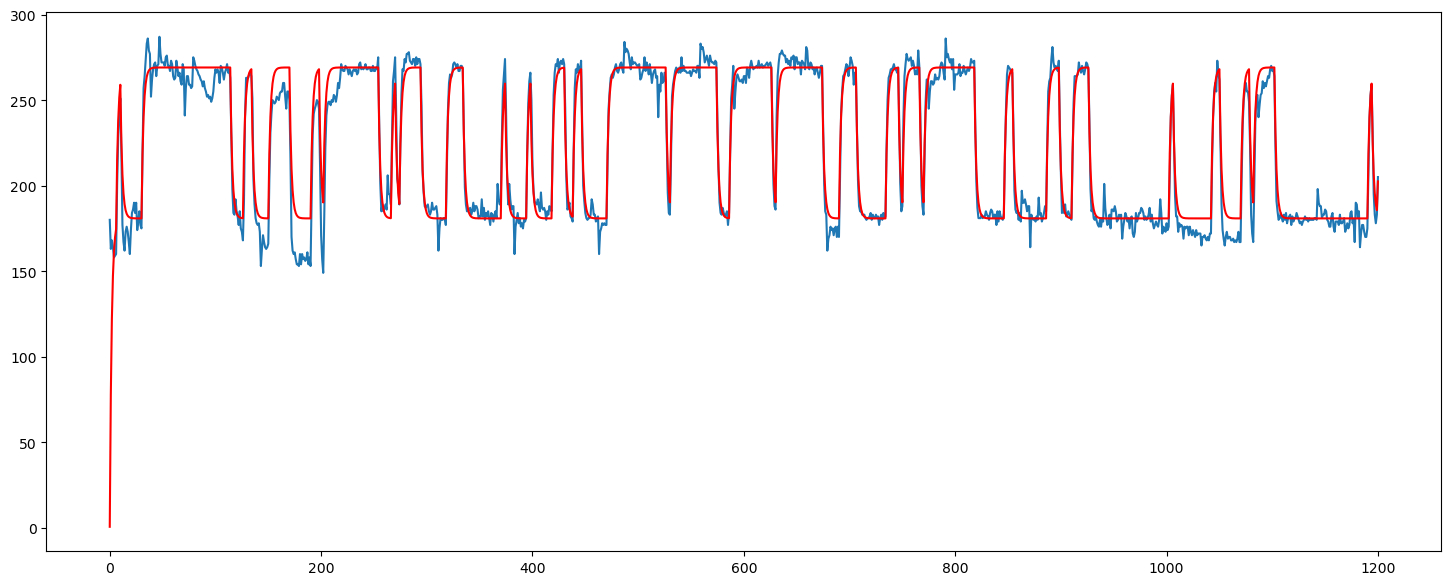

In [59]:
df['V_c [ml/min]'].plot()
df['V_c_est_4'].plot(color = 'red', figsize = [18,7])

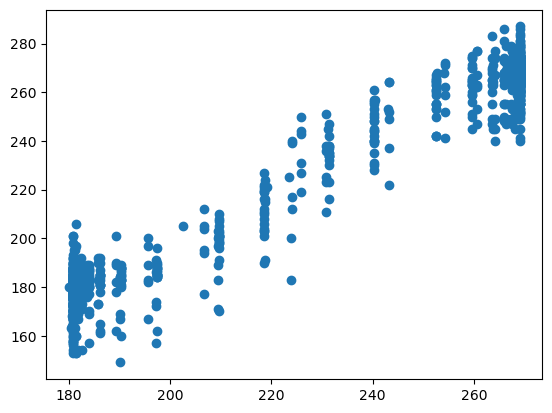

In [60]:
# Correct starting point

# Initialize the 'new' column with NaN
df['V_c_est_4'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'V_c_est_4'] = 180.0

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'V_c_est_4'] = model.const_1.item()*np.maximum(df.at[i-1, 'u_c [%]'] - 19.0, 0.0) + model.const_2.item()*df.at[i-1, 'V_c_est_4'] 

x = df['V_c_est_4']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

<Axes: >

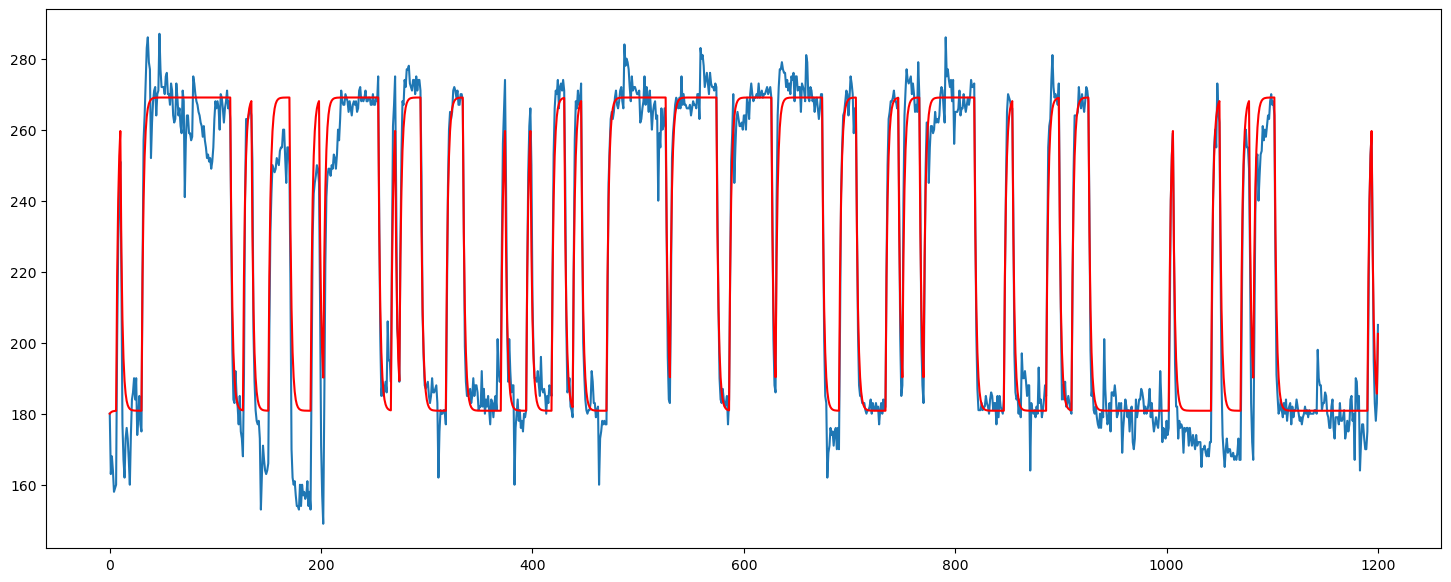

In [61]:
df['V_c [ml/min]'].plot()
df['V_c_est_4'].plot(color = 'red', figsize = [18,7])

In [62]:
# model
class ProcessModel(torch.nn.Module):
    def __init__(self):
        super(ProcessModel, self).__init__()
        self.const_1 = torch.nn.Parameter(torch.rand(1,1))
        self.const_2 = torch.nn.Parameter(torch.rand(1,1))
        self.min_u = torch.nn.Parameter(torch.rand(1,1))
        
    def forward(self, x):
        # ['u_c_k-1 [%]', 'V_c_k-1 [ml/min]']
        x = self.const_1*torch.max(x[:,0]-self.min_u, torch.tensor(0.0)) + self.const_2*x[:,1]
        x = x.transpose(0, 1)
        return x

In [63]:
# Load model to device
model = ProcessModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [64]:
epochs = 5000
min_loss = float('inf')
for t in range(epochs):
    if (t + 1) % 100 == 0:  # Print every 100 epochs
        print(f"Epoch {t+1}: ")
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=True)
    else:
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=False)
print("Done!")

New best model found! Saving model, MSE: 82.140381, MAE: 6.176146
New best model found! Saving model, MSE: 81.743706, MAE: 6.163747
New best model found! Saving model, MSE: 79.562065, MAE: 6.136250
New best model found! Saving model, MSE: 78.416069, MAE: 6.066640
New best model found! Saving model, MSE: 76.481308, MAE: 6.000479
New best model found! Saving model, MSE: 76.399277, MAE: 6.035916
New best model found! Saving model, MSE: 74.423859, MAE: 5.966775
New best model found! Saving model, MSE: 74.100357, MAE: 5.960789
New best model found! Saving model, MSE: 73.437988, MAE: 5.987929
New best model found! Saving model, MSE: 72.701729, MAE: 5.956488
New best model found! Saving model, MSE: 72.368362, MAE: 5.996198
New best model found! Saving model, MSE: 71.974854, MAE: 5.986484
New best model found! Saving model, MSE: 71.854340, MAE: 6.031653
New best model found! Saving model, MSE: 71.335907, MAE: 6.011596
New best model found! Saving model, MSE: 70.522964, MAE: 6.030639
New best m

In [65]:
model.load_state_dict(torch.load("best_model_pv.pth"))

<All keys matched successfully>

In [66]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

const_1 tensor([[1.8964]], device='mps:0')
const_2 tensor([[0.5826]], device='mps:0')
min_u tensor([[20.3519]], device='mps:0')


In [67]:
model.const_1.item()

1.896369457244873

In [68]:
model.const_2.item()

0.5825537443161011

In [69]:
model.min_u.item()

20.35188865661621

In [70]:
T_s = 1
T = T_s / (1.0 - model.const_2.item())
T

2.3955179532313875

In [71]:
K = model.const_1.item() / (T_s / T)
K

4.542787080789755

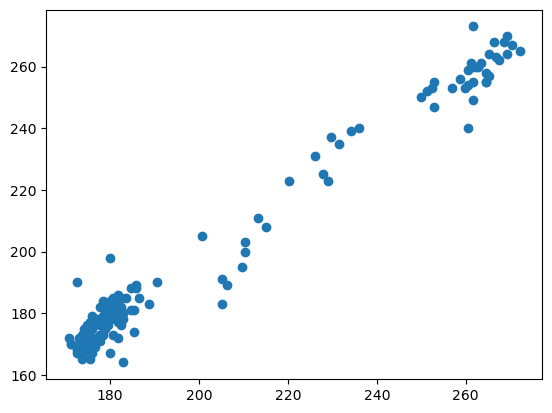

Avg loss MSE: 34.061092, MAE: 4.219151



In [72]:
testing(test_dataloader, model, loss_fn, loss_fn2)

In [73]:
df['V_c_est_5'] = model.const_1.item()*np.maximum(df['u_c_k-1 [%]'] - model.min_u.item(), 0.0) + model.const_2.item() * df['V_c_k-1 [ml/min]']

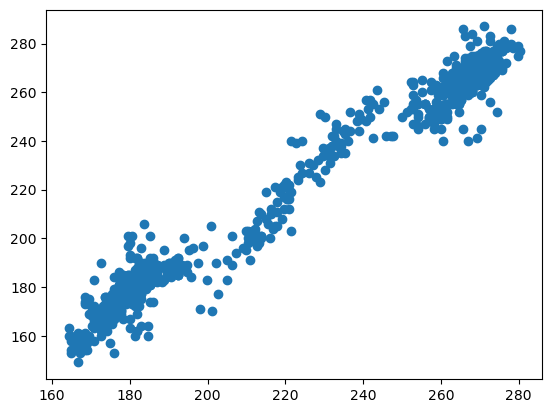

In [74]:
x = df['V_c_est_5']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

<Axes: >

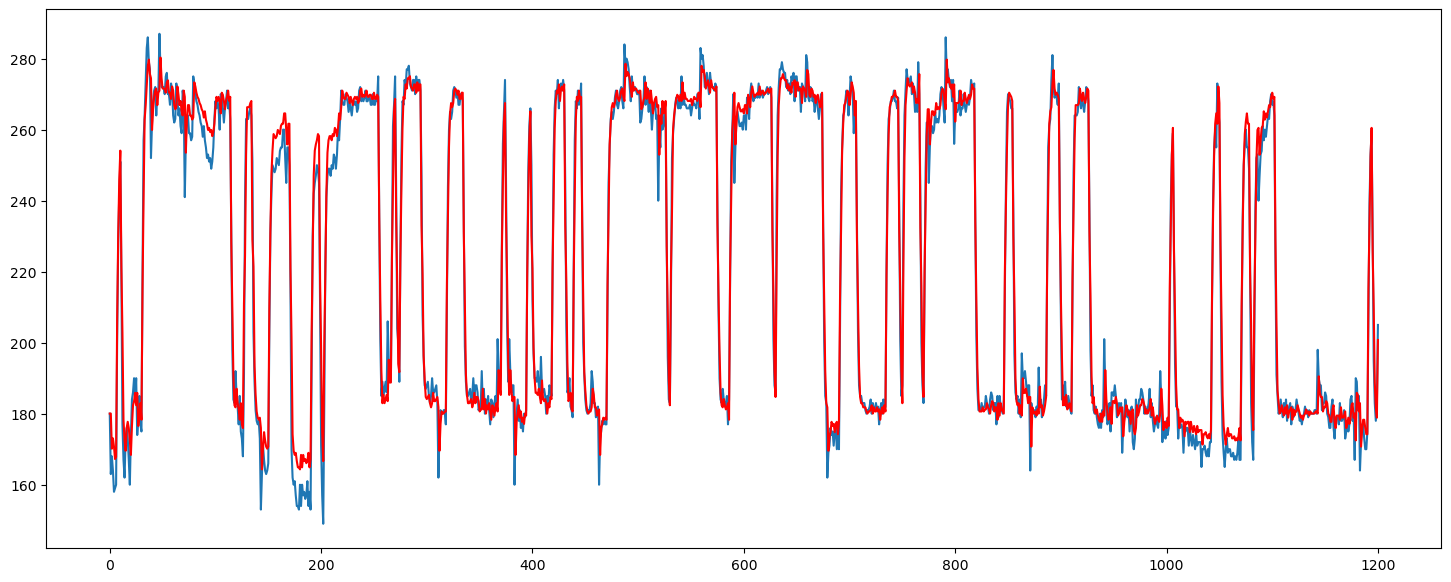

In [75]:
df['V_c [ml/min]'].plot()
df['V_c_est_5'].plot(color = 'red', figsize = [18,7])

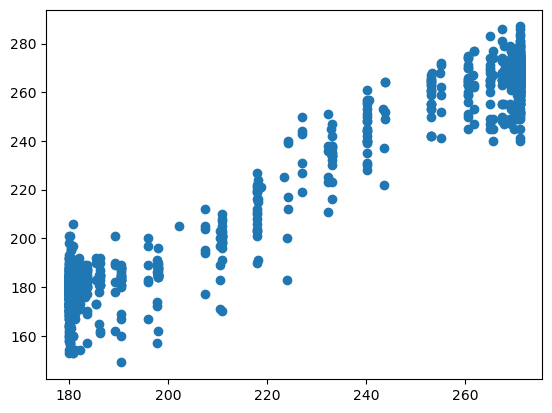

In [76]:
# Correct starting point

# Initialize the 'new' column with NaN
df['V_c_est_6'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'V_c_est_6'] = 180.0

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'V_c_est_6'] = model.const_1.item()*np.maximum(df.at[i-1, 'u_c [%]'] - model.min_u.item(), 0.0) + model.const_2.item()*df.at[i-1, 'V_c_est_6'] 

x = df['V_c_est_6']
y = df['V_c [ml/min]']

plt.scatter(x, y)
plt.show()

<Axes: >

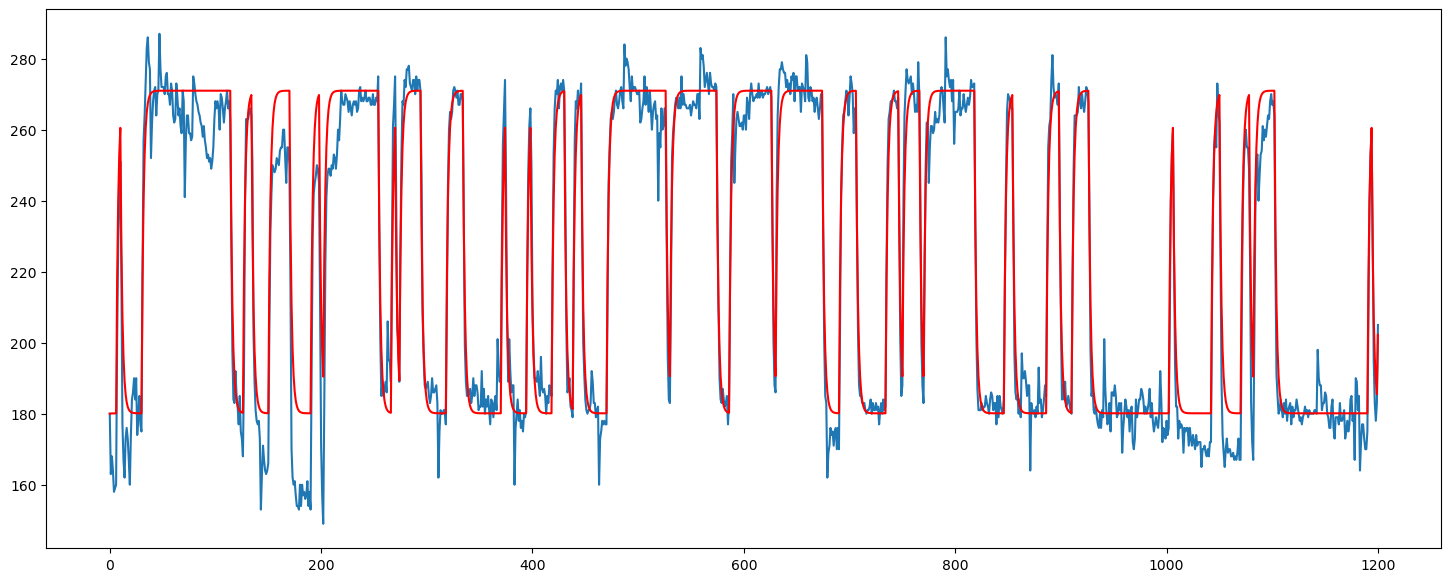

In [77]:
df['V_c [ml/min]'].plot()
df['V_c_est_6'].plot(color = 'red', figsize = [18,7])

## Process variable P

<Axes: >

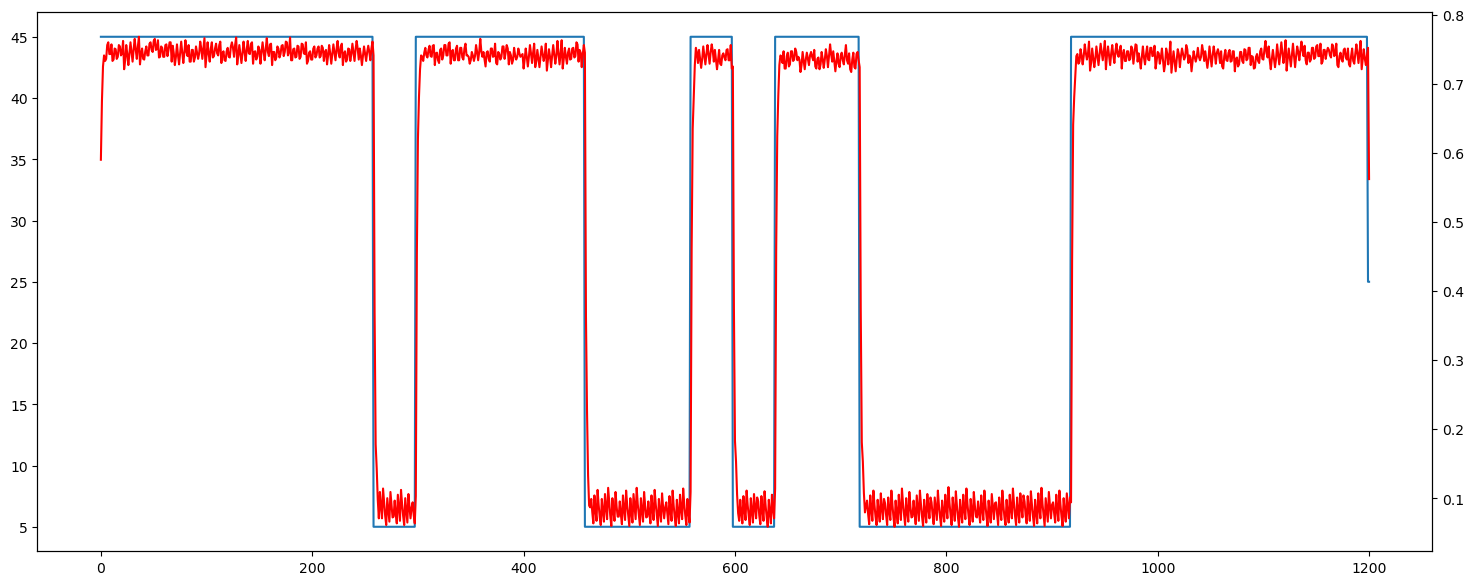

In [78]:
df['u_p [%]'].plot()
df['P [kW]'].plot(secondary_y=True, color = 'red', figsize = [18,7])

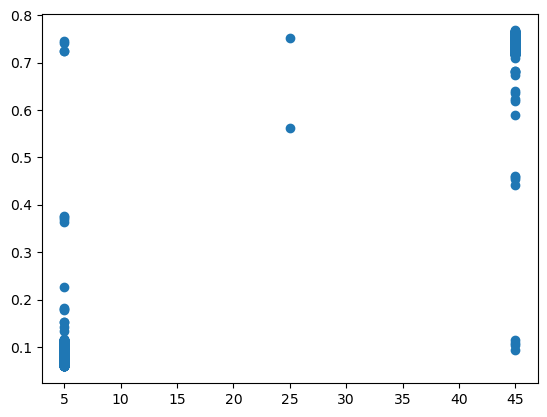

In [79]:
x = df['u_p [%]']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

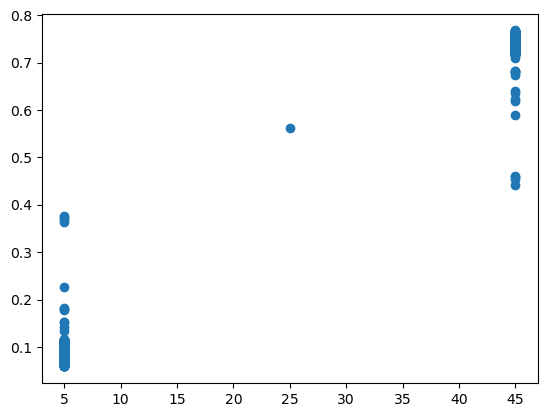

In [80]:
x = df['u_p_k-1 [%]']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

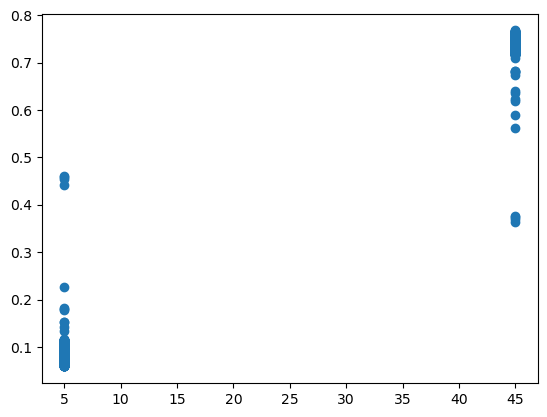

In [81]:
x = df['u_p_k-2 [%]']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

In [82]:
Ts = 1
K = 0.016
T = 1

df['P_est'] = Ts*K/T*df['u_p_k-1 [%]'] + (1 - Ts/T) * df['P_k-1 [kW]']

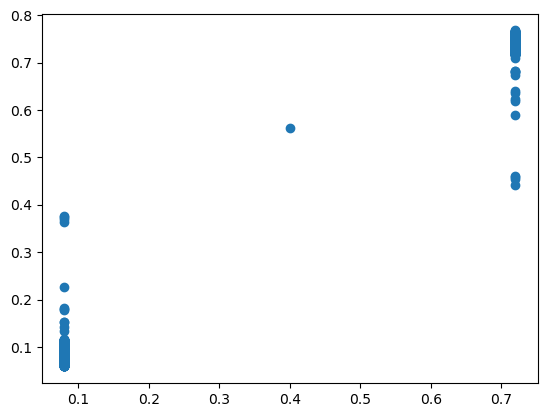

In [83]:
x = df['P_est']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

<Axes: >

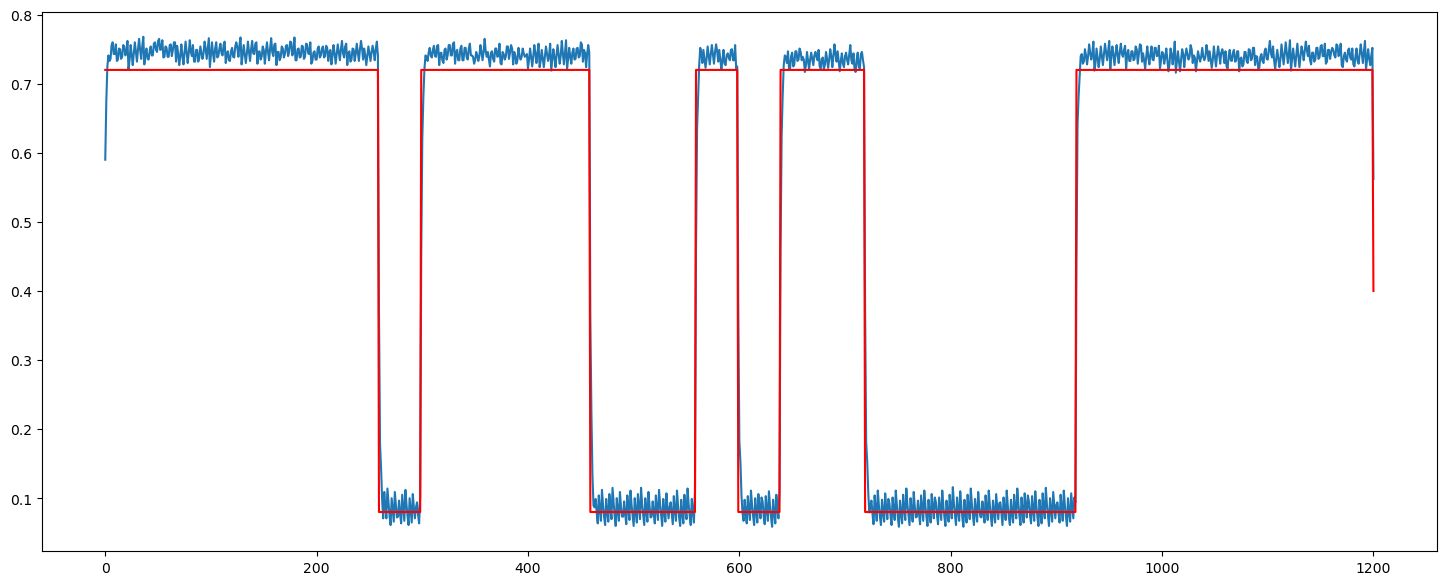

In [84]:
df['P [kW]'].plot()
df['P_est'].plot(color = 'red', figsize = [18,7])

In [85]:
# Starting point
df.at[0, 'P [kW]']

0.59

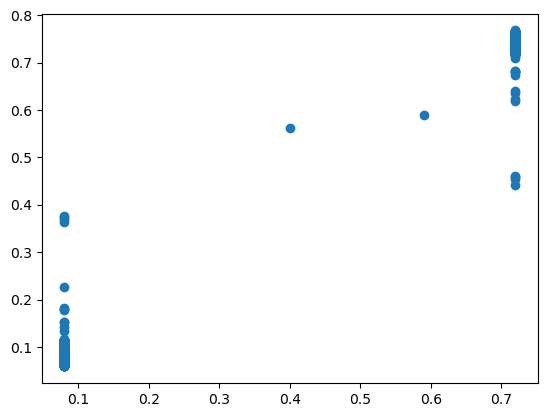

In [86]:
# Initialize the 'new' column with NaN
df['P_est_2'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'P_est_2'] = 0.59  # You can choose any starting value for the first row

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'P_est_2'] = Ts*K/T*np.maximum(df.at[i-1, 'u_p [%]']-0.0, 0.0) + (1 - Ts/T) * df.at[i-1, 'P_est_2']

x = df['P_est_2']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

<Axes: >

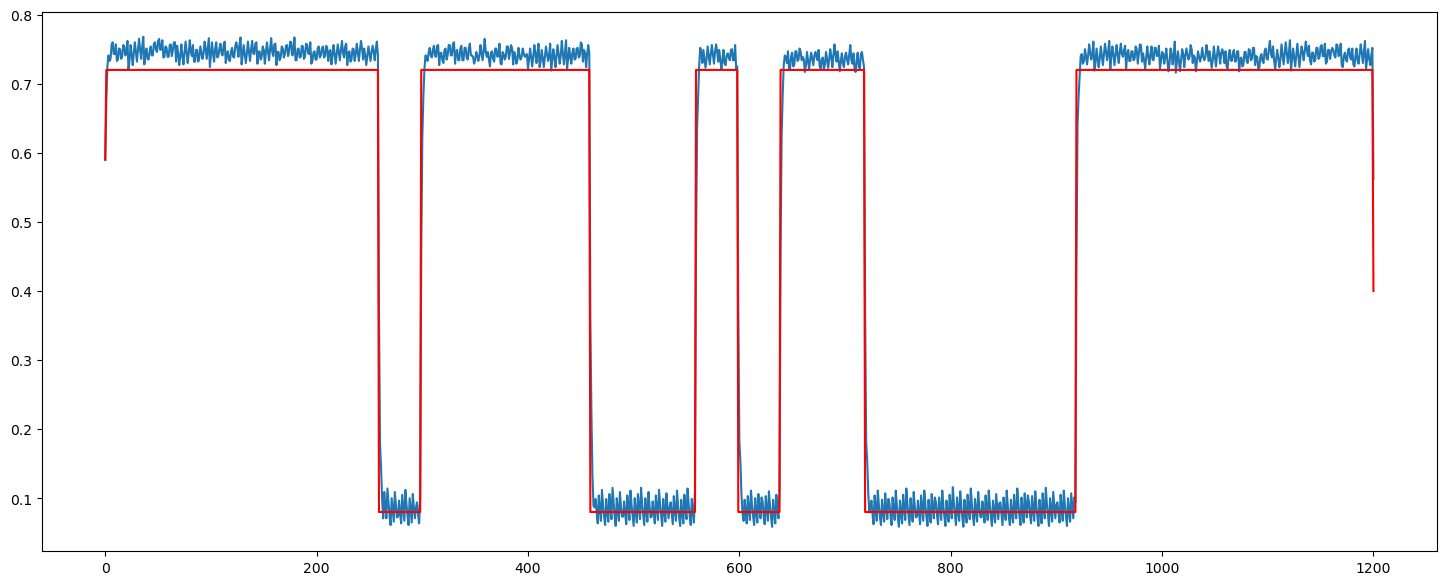

In [87]:
df['P [kW]'].plot()
df['P_est_2'].plot(color = 'red', figsize = [18,7])

In [88]:
features = ['u_p_k-1 [%]', 'P_k-1 [kW]']
targets = ['P [kW]']

In [89]:
# Dataloader
from torch.utils.data import DataLoader

train_myDs=MyDataset(train_df, features, targets)
train_dataloader = DataLoader(train_myDs,batch_size=512,shuffle=True, worker_init_fn=lambda worker_id: np.random.seed(seed + worker_id))

valid_myDs=MyDataset(valid_df, features, targets)
valid_dataloader = DataLoader(valid_myDs,batch_size=512,shuffle=True, worker_init_fn=lambda worker_id: np.random.seed(seed + worker_id))

test_myDs=MyDataset(test_df, features, targets)
test_dataloader = DataLoader(test_myDs,batch_size=512,shuffle=True, worker_init_fn=lambda worker_id: np.random.seed(seed + worker_id))

In [90]:
# model
class ProcessModel(torch.nn.Module):
    def __init__(self):
        super(ProcessModel, self).__init__()
        self.const_1 = torch.nn.Parameter(torch.rand(1,1))
        self.const_2 = torch.nn.Parameter(torch.rand(1,1))
        self.min_u = torch.tensor(0.0)
        
    def forward(self, x):
        # ['u_c_k-1 [%]', 'V_c_k-1 [ml/min]']
        x = self.const_1*torch.max(x[:,0]-self.min_u, torch.tensor(0.0)) + self.const_2*x[:,1]
        x = x.transpose(0, 1)
        return x

In [91]:
# Load model to device
model = ProcessModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [92]:
epochs = 5000
min_loss = float('inf')
for t in range(epochs):
    if (t + 1) % 100 == 0:  # Print every 100 epochs
        print(f"Epoch {t+1}: ")
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=True)
    else:
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=False)
print("Done!")

New best model found! Saving model, MSE: 242.761719, MAE: 12.624139
New best model found! Saving model, MSE: 80.464325, MAE: 7.267496
New best model found! Saving model, MSE: 8.367922, MAE: 2.342828
New best model found! Saving model, MSE: 4.875580, MAE: 1.790158
New best model found! Saving model, MSE: 0.159563, MAE: 0.324031
New best model found! Saving model, MSE: 0.048905, MAE: 0.178965
New best model found! Saving model, MSE: 0.006396, MAE: 0.065565
New best model found! Saving model, MSE: 0.002042, MAE: 0.033584
New best model found! Saving model, MSE: 0.001771, MAE: 0.033964
New best model found! Saving model, MSE: 0.000919, MAE: 0.021216
New best model found! Saving model, MSE: 0.000743, MAE: 0.016252
New best model found! Saving model, MSE: 0.000704, MAE: 0.013659
New best model found! Saving model, MSE: 0.000696, MAE: 0.013844
New best model found! Saving model, MSE: 0.000693, MAE: 0.013931
New best model found! Saving model, MSE: 0.000693, MAE: 0.014093
New best model found!

In [93]:
model.load_state_dict(torch.load("best_model_pv.pth"))

<All keys matched successfully>

In [94]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

const_1 tensor([[0.0098]], device='mps:0')
const_2 tensor([[0.4038]], device='mps:0')


In [95]:
model.const_1.item()

0.009805653244256973

In [96]:
model.const_2.item()

0.4038463234901428

In [97]:
model.min_u.item()

0.0

In [98]:
T_s = 1
T = T_s / (1.0 - model.const_2.item())
T

1.6774198321721923

In [99]:
K = model.const_1.item() / (T_s / T)
K

0.016448197219320244

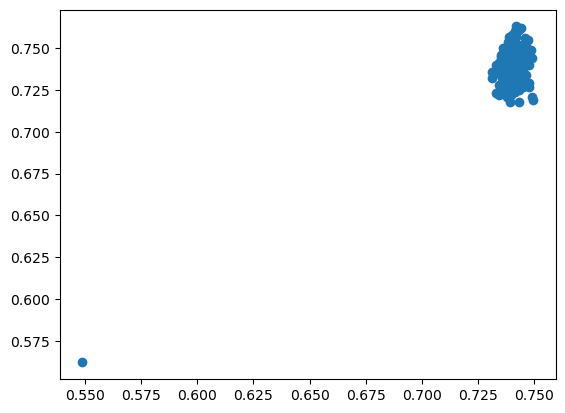

Avg loss MSE: 0.000117, MAE: 0.009223



In [100]:
testing(test_dataloader, model, loss_fn, loss_fn2)

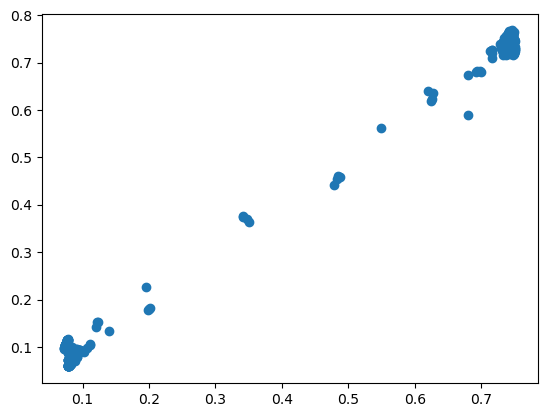

In [101]:
df['P_est_3'] = model.const_1.item()*np.maximum(df['u_p_k-1 [%]']-model.min_u.item(), 0.0)  + model.const_2.item()*df['P_k-1 [kW]']
x = df['P_est_3']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

<Axes: >

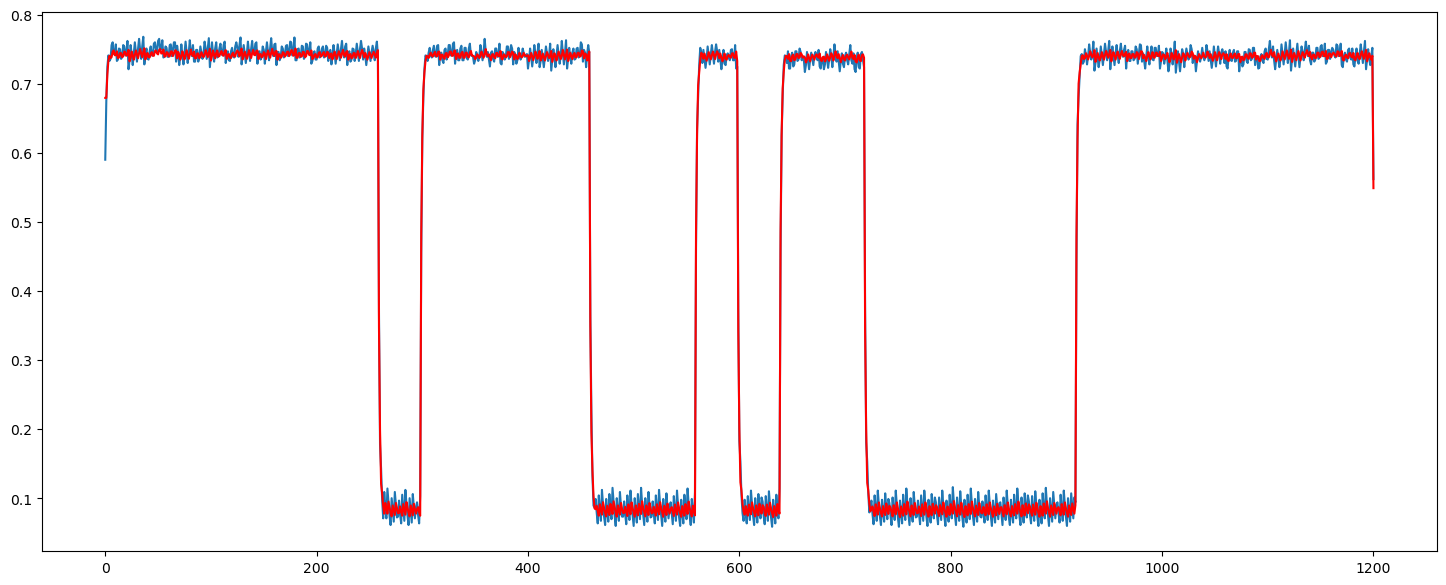

In [102]:
df['P [kW]'].plot()
df['P_est_3'].plot(color = 'red', figsize = [18,7])

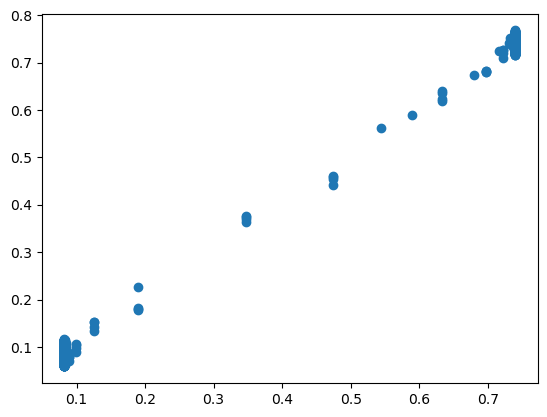

In [103]:
# Initialize the 'new' column with NaN
df['P_est_4'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'P_est_4'] = 0.59  # You can choose any starting value for the first row

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'P_est_4'] = model.const_1.item()*np.maximum(df.at[i-1, 'u_p [%]']-model.min_u.item(), 0.0) + model.const_2.item()*df.at[i-1, 'P_est_4']

x = df['P_est_4']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

<Axes: >

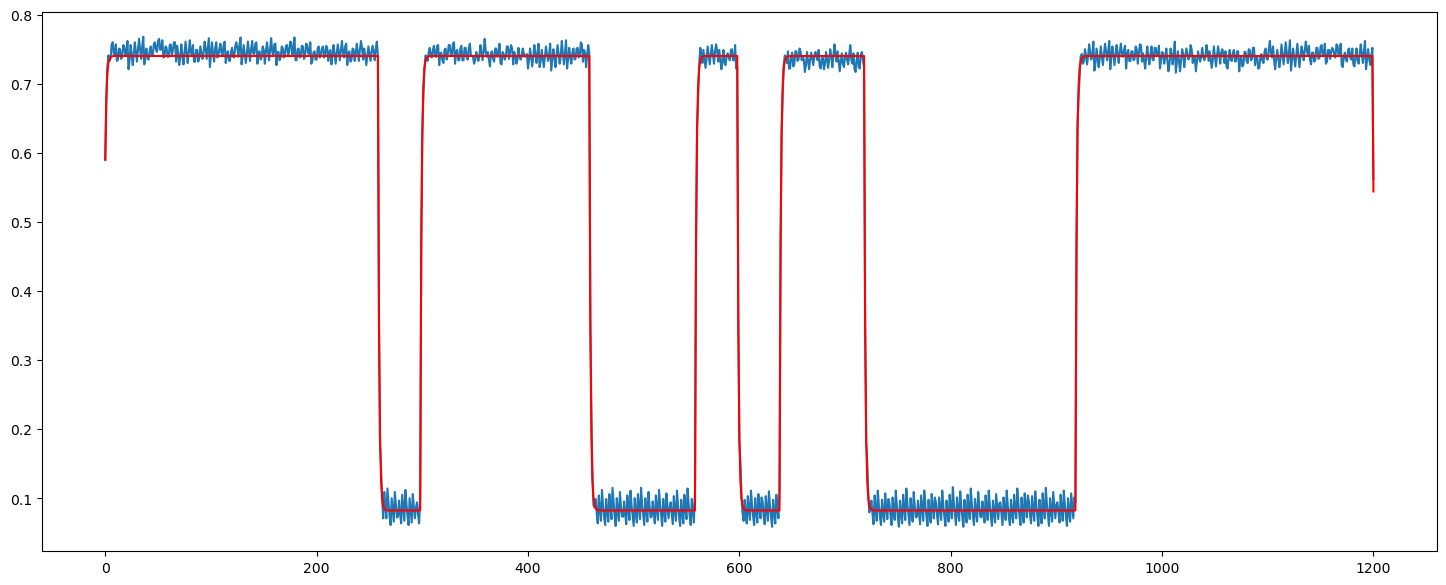

In [104]:
df['P [kW]'].plot()
df['P_est_4'].plot(color = 'red', figsize = [18,7])

In [105]:
# model
class ProcessModel(torch.nn.Module):
    def __init__(self):
        super(ProcessModel, self).__init__()
        self.const_1 = torch.nn.Parameter(torch.rand(1,1))
        self.const_2 = torch.nn.Parameter(torch.rand(1,1))
        self.min_u = torch.nn.Parameter(torch.rand(1,1))
        
    def forward(self, x):
        # ['u_c_k-1 [%]', 'V_c_k-1 [ml/min]']
        x = self.const_1*torch.max(x[:,0]-self.min_u, torch.tensor(0.0)) + self.const_2*x[:,1]
        x = x.transpose(0, 1)
        return x

In [106]:
# Load model to device
model = ProcessModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [107]:
epochs = 5000
min_loss = float('inf')
for t in range(epochs):
    if (t + 1) % 100 == 0:  # Print every 100 epochs
        print(f"Epoch {t+1}: ")
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=True)
    else:
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=False)
print("Done!")

New best model found! Saving model, MSE: 1.929958, MAE: 1.115758
New best model found! Saving model, MSE: 0.105881, MAE: 0.261541
New best model found! Saving model, MSE: 0.007465, MAE: 0.071707
New best model found! Saving model, MSE: 0.007085, MAE: 0.069840
New best model found! Saving model, MSE: 0.000927, MAE: 0.024614
New best model found! Saving model, MSE: 0.000566, MAE: 0.015441
New best model found! Saving model, MSE: 0.000559, MAE: 0.015353
New best model found! Saving model, MSE: 0.000551, MAE: 0.015226
New best model found! Saving model, MSE: 0.000550, MAE: 0.015221
New best model found! Saving model, MSE: 0.000549, MAE: 0.015213
New best model found! Saving model, MSE: 0.000549, MAE: 0.015208
New best model found! Saving model, MSE: 0.000547, MAE: 0.015171
New best model found! Saving model, MSE: 0.000546, MAE: 0.015173
New best model found! Saving model, MSE: 0.000544, MAE: 0.015137
New best model found! Saving model, MSE: 0.000544, MAE: 0.015129
New best model found! Sav

In [108]:
model.load_state_dict(torch.load("best_model_pv.pth"))

<All keys matched successfully>

In [109]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

const_1 tensor([[0.0092]], device='mps:0')
const_2 tensor([[0.4636]], device='mps:0')
min_u tensor([[1.5436]], device='mps:0')


In [110]:
model.const_1.item()

0.009154325351119041

In [111]:
model.const_2.item()

0.4635534882545471

In [112]:
model.min_u.item()

1.5436192750930786

In [113]:
T_s = 1
T = T_s / (1.0 - model.const_2.item())
T

1.8641187482909871

In [114]:
K = model.const_1.item() / (T_s / T)
K

0.01706474951497648

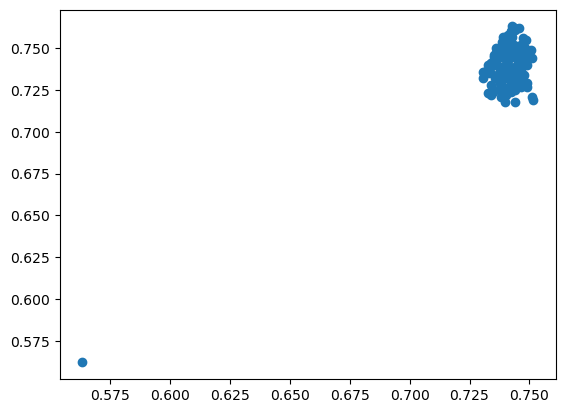

Avg loss MSE: 0.000121, MAE: 0.009405



In [115]:
testing(test_dataloader, model, loss_fn, loss_fn2)

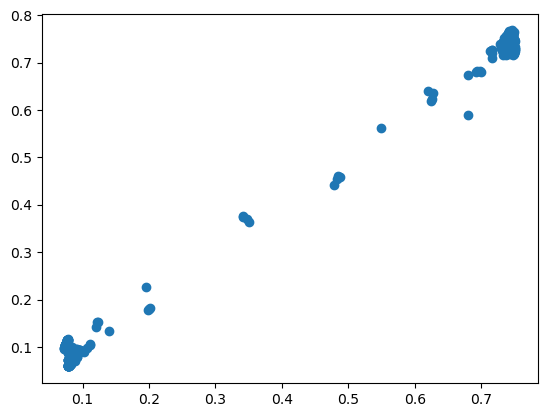

In [116]:
df['P_est_5'] = model.const_1.item()*np.maximum(df['u_p_k-1 [%]']-model.min_u.item(), 0.0)  + model.const_2.item()*df['P_k-1 [kW]']
x = df['P_est_3']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

<Axes: >

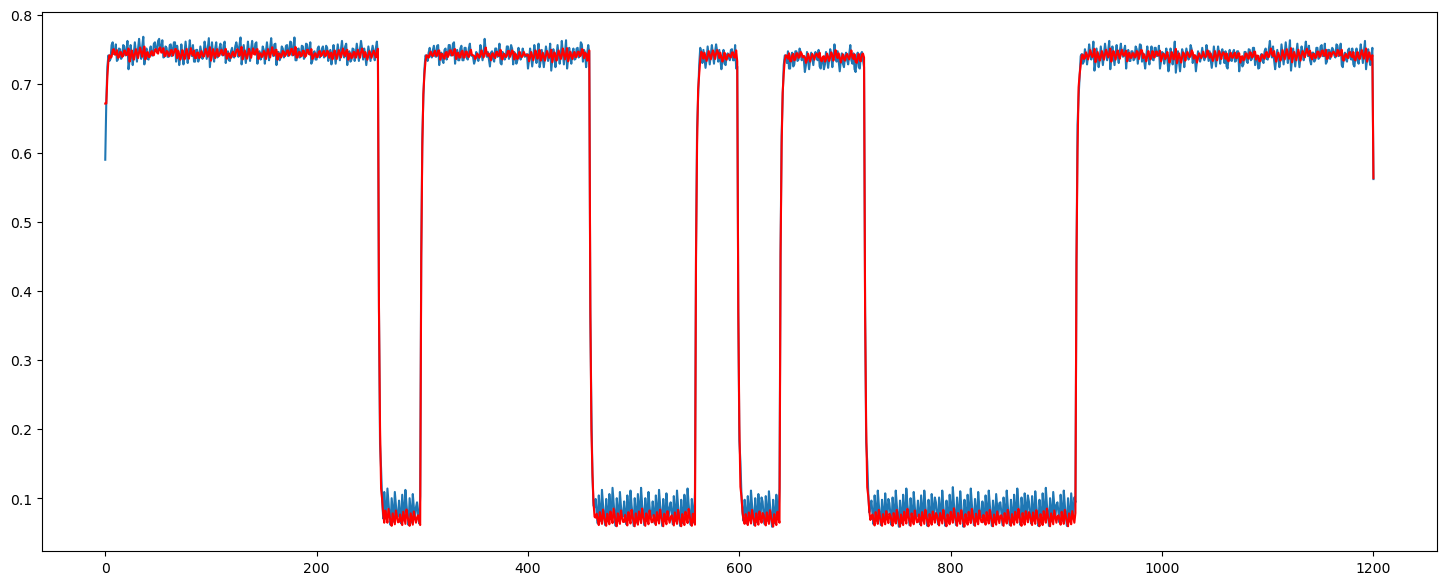

In [117]:
df['P [kW]'].plot()
df['P_est_5'].plot(color = 'red', figsize = [18,7])

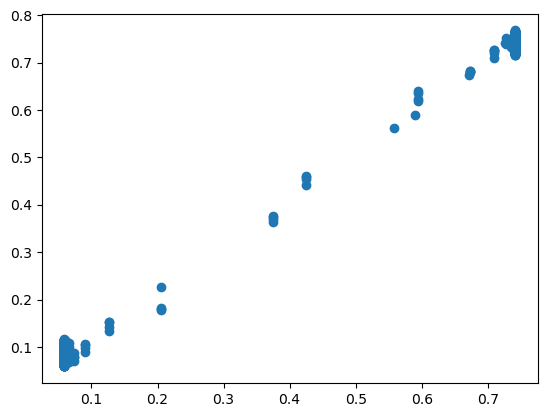

In [118]:
# Initialize the 'new' column with NaN
df['P_est_6'] = float('nan')

# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'P_est_6'] = 0.59  # You can choose any starting value for the first row

# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'P_est_6'] = model.const_1.item()*np.maximum(df.at[i-1, 'u_p [%]']-model.min_u.item(), 0.0) + model.const_2.item()*df.at[i-1, 'P_est_6']

x = df['P_est_6']
y = df['P [kW]']

plt.scatter(x, y)
plt.show()

<Axes: >

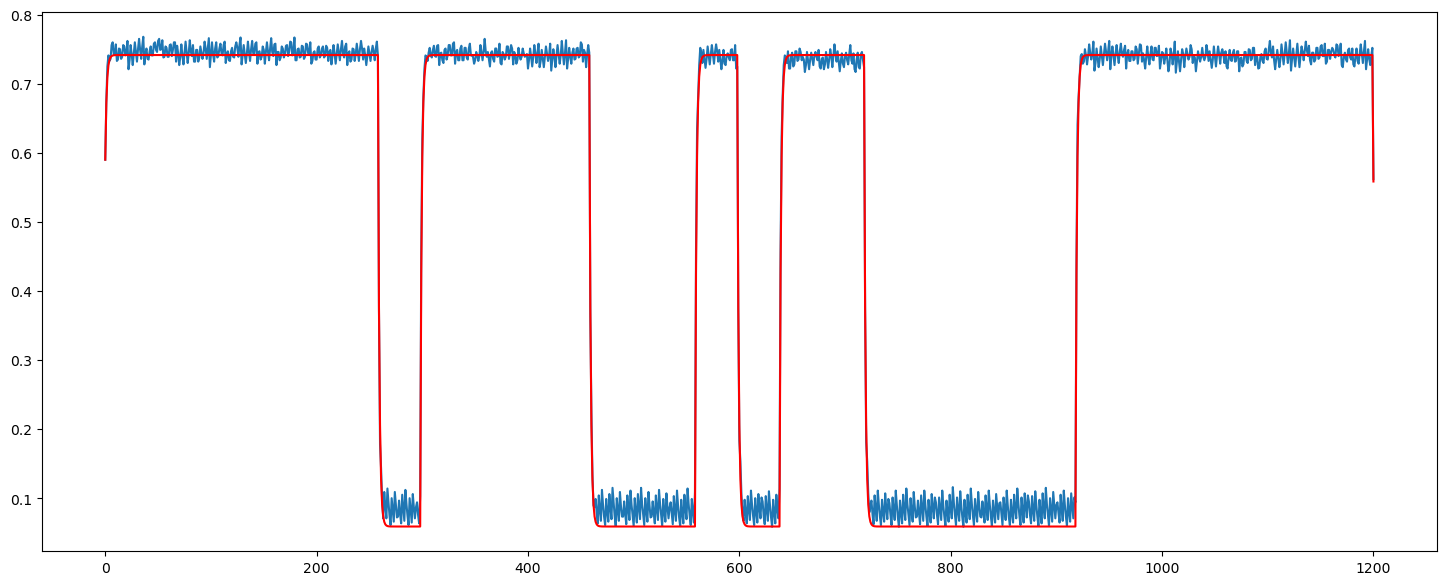

In [119]:
df['P [kW]'].plot()
df['P_est_6'].plot(color = 'red', figsize = [18,7])